# Notes

# Import Objects

## Modules

In [1]:
#__ importing libraries, modules, and packages __#

# TODO: check for package updates, install(?) and/or note the version 
# numbers (need to figure out virtual environments...) 
# <2026-05-13>

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
# import datetime as dt
import geopandas as gpd
# import geodatasets as gds
# import shapely.geometry as geo
import glob
import calendar as cal
# from mpl_toolkits.axes_grid1 import make_axes_locatable
from math import log10, floor
import pickle
# import dataframe_image as dfi
import statsmodels.api as sm
import statsmodels.formula.api as smf
import folium

In [2]:
#__ expand dataframe display __#

# easily/ automatically view all rows and all columns
pd.set_option("display.max_rows", None, "display.max_columns", None)

## Variables

In [3]:
#__ different lists of months for sorting & organizing date data __#

ref_month_list = pd.Series(['January', 'February', 'March', 
                            'April', 'May', 'June', 
                            'July', 'August', 'September', 
                            'October', 'November', 'December'])
ref_month_num = list(ref_month_list.index+1)
# XXX: variable not used after definition, consider removing <2026-05-12>
# months_ordered = [f'{r:02}-' for r in ref_month_num] + ref_month_list
ref_month_dict = {x: y 
                  for x in ref_month_list
                  for y in ref_month_num 
                  if ref_month_list[y-1] == x}

In [4]:
#__ define full date ranges of all reports included __#

# XXX: none of these variables are used elsewhere, consider removing 
# <2026-05-12>

# full_day_range = pd.Series(pd.date_range(start='2013-01-01', end='2024-12-31', freq='D'))
# full_day_range = pd.DataFrame({'Date': full_day_range,
#                                'Year': full_day_range.dt.year,
#                                'Month': full_day_range.dt.month})

# full_month_range = pd.Series(pd.date_range(start='2013-01-01', end='2024-12-31', freq='MS'))
# full_month_range = pd.DataFrame({'Date': full_month_range, 'Days in Month': full_month_range.dt.days_in_month})

## Functions

In [5]:
def fxn_round_sigfigs(number, precision = 3):
    '''Round a number to the specified number of significant figures.

    Parameters
    ----------
    number : float or int
        The number to round.
    precision : int>0, default=3
        How many significant figures to include. Starts from the 
        leftmost digit of the number. Must be positive.

    Returns
    -------
    float
        The rounded number.
    '''
    if number == 0:
        return 0
    return round(number, precision - int(floor(log10(abs(number)))) - 1)

In [6]:
def fxn_excel_import(file_path: str, inc_sheets='all', og_sheet_names=False,
                    #  headers = 0, index = None, 
                    #  skip_n_rows = None, col_names = None,
                    #  select_cols = None
                     **kwargs):
    '''Import excel workbooks into a dictionary of Pandas dataframes.

    Parameters
    ----------
    file_path : str
        The path to the excel workbook .xlsx file. Can be absolute or relative. Use backslashes "/" in the path string.
    inc_sheets : {'all','end'} or int, default='all'
        Number of sheets to include in the import.
        Available cases:
        - Defaults to 'all': Import all worksheets
        - 'end': Import only the last worksheet
        - int: Loads the first *n* sheets of the workbook (place all unwanted sheets at the end)
    og_sheet_names : bool, default=False
        Whether to keep the original, altered sheet names as the dataframe titles. If `False`, will convert all letters to lowercase and replace all spaces with underscores.
    **kwargs
        Keyword arguments to pass to `pd.ExcelFile.parse()`

    Returns
    -------
    Dataframe or dict of DataFrames
        DataFrame from the passed in Excel file. 
        - If only importing one (1) sheet, function will output a pd.DataFrame from that sheet
        - otherwise, if importing >1 sheet, function will output a dict with each sheet as a key

    See Also
    --------
    pd.ExcelFile.parse :  Parse specified sheet(s) into a DataFrame.   
    
    Notes
    -----
    Important: be sure that there is at most 1 header row for each sheet of interest

    file_path notes:
        - for a file within the current folder: "subfolder1/subfolder2/.../file.xlsx"
        - use "../" to go 1 level up from the current folder ("../../" for 2 levels, etc.)
    '''
    
    data_file = pd.ExcelFile(file_path)
    data = {}

    if inc_sheets == 'all':
        sheets_import = data_file.sheet_names
    elif inc_sheets == 'end':
        sheets_import = [data_file.sheet_names[-1]]
    else:
        sheets_import = data_file.sheet_names[0:inc_sheets]

    if og_sheet_names == False:
        for sheet in sheets_import:
            data[f'{sheet.lower().replace(' ','_')}'] = data_file.parse(sheet, **kwargs)#skiprows=skip_n_rows, names=col_names, usecols=select_cols)
    else:
        for sheet in sheets_import:
            data[sheet] = data_file.parse(sheet, **kwargs)#skiprows=skip_n_rows, names=col_names, usecols=select_cols)
    
    if sheets_import.__len__() == 1:
        data = data[list(data.keys())[0]]

    return data

In [7]:
def fxn_construct_table(df: pd.DataFrame, index: list, columns: list):
    '''Creates a new DataFrame from chosen index and columns.

    Intended as a shorthand for making a new dataframe from an existing one.
    Checks to make sure selected index column(s) result in a unique index.

    Paramaters
    ----------
    df : pd.DataFrame
        The DataFrame to create the new table from.
        For best use, do not have any index columns in the passed DataFrame.
    index : list of str
        A list of columns from the DataFrame to form the new index.
        Cannot be columns in an existing index.
    columns : list of str or 'all'
        A list of columns from the DataFrame to include in the new one.
        Cannot be columns in an existing index.
        To include all columns, pass in 'all' here.

    Returns
    -------
    pd.DataFrame
    '''
    if df[index].drop_duplicates().__len__() < df[index].__len__():
        raise Exception('Chosen index is not unique. Select column(s) that ' \
                        'will yield unique values in the index for each row.')
    data = df.set_index(index).sort_index()
    if columns == 'all':
        return data
    else:
        return data[columns]

In [8]:
def fxn_df_duplicates(df: pd.DataFrame, columns: list, type='check', 
                      indexed=True, sort_col='same'):
    '''Finds and handles duplicates in a DataFrame.

    Finds duplicate rows based on designated columns in a DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        The DataFrame to check duplicates in.
    columns : list of str
        A list of the column names to check for duplicates within.
    type : {'check','find','drop'}, default 'check'
        The type of duplicate process to complete.
        Available cases:
        - 'check': Returns str stating whether duplicates were detected
        - 'find': Returns pd.DataFrame containing all duplicate entries
        - 'drop': Returns pd.DataFrame with all but the first entry dropped
    indexed : bool, default `True`
        Only applies when type is 'drop'.
        If `True`, sets the passed columns as the new index of the resulting DataFrame.
    sort_col : 'same' or list of str, default 'same'
        Only applies when type is 'drop' to determine the first duplicate
        entry that will not be dropped.
        If 'same', will sort by 'columns' in the order listed.
        If a list of column names is passed, will instead sort by that in 
        the order listed.

    Returns
    -------
    type = 'check' : str
    type = {'find','drop'} : pd.DataFrame
    '''
    if type == 'check':
        if df[columns].drop_duplicates().__len__() < df[columns].__len__():
            print('Duplicates detected')
        else:
            print('No duplicates found -- entries are unique for the selected columns')
    elif type == 'find':
        df = df.set_index(columns)
        return df.loc[df.index.duplicated(keep=False), :]
    elif type == 'drop':
        df = df.sort_values(columns if sort_col == 'same' else sort_col,
                            ascending=False
                           ).drop_duplicates(subset=columns,
                                             keep='first')
        if indexed:
            return df.set_index(columns).sort_index()
        else:
            return df

In [9]:
def fxn_pretty_table(styler, title: str, description: str):
    '''Sets table styles and displays defined metadata.

    Must be used as a styler method:  
    `df.style.pipe(fxn_pretty_table, title='', description='')`

    Parameters
    ----------
    title : str
        Define the title of the table. 
        Flows into the "caption" styler.
    description : str
        Provide additional information about the table. 
        Flows into the "caption" styler.
    
    Returns
    -------
    Displays dataframe as a table with a more standard style applied.

    Notes
    -----
    TODO: When needing stadardized tables to export, fix up this function
    to (a) export the table somehow and (b) have the style be what I need
    for that export.
    <2026-05-20>
    '''
    caption = f'{title}<br><span style="font-size:12px; font-style:italic; font-weight:normal">{description}<br></span>'
    
    styler.set_caption(caption)
    styler.set_table_styles([{
        'selector': 'caption',
        'props': 'font-weight:bold; font-size:1.25em;'
    }])
    styler.set_sticky(axis='columns')
    return styler

In [10]:
def fxn_convert_to_gallons(value, units, target_unit='gal'):
    '''Converts value to gallons (or from kilogallons to gallons).

    Parameters
    ----------
    value : float
        The value to be converted.
    units : str
        The starting units of the value.
        If `target_unit` is 'gal', `units` can be either the long form 
        or shorthand of typical measures of measuring water to then convert 
        to gallons:
        - 'Gallons Thousands' or 'kgal'
        - 'Gallons Millions' or 'Mgal'
        - 'CCF (100 cubic feet)' or 'ccf'
        - 'Acre-feet' or 'af'
        If `target_unit` is 'kgal', must be 'gal' or 'Gallons'.
    target_unit : {'gal','kgal'}
        The units to convert the value to.
    
    Returns
    -------
    float
        The converted value.
    '''
    if target_unit == 'gal':
        if units == 'Gallons Thousands' or units == 'kgal':
            if target_unit == 'kgal':
                return value
            elif target_unit == 'gal':
                return value * 1000
        # below else's assume target_unit == gal
        elif units == 'Gallons Millions' or units == 'Mgal':
            converted = value * 1000000
        elif units == 'CCF (100 cubic feet)' or units == 'ccf':
            converted = value * 748.0519480519
        elif units == 'Acre-feet' or units == 'af':
            converted = value * 325851.42857143
        else:
            converted = value
    elif target_unit == 'kgal' and units in ('gal','Gallons'):
        converted = value / 1000
    else:
        raise('Invalid units selected, please try again.')
    
    return converted

In [11]:
def fxn_gpcd(data,pop_type='both',cols_return='GPCD',
             permanent_pop_col=None,transient_pop_col=None,total_pop_col=None
             ):
    '''Calculates the gallons per capita day from provided water use and population.

    Parameters
    ----------
    data : pd.DataFrame
        The dataframe to pass in. Must have the first column hold the water use data 
        **in gallons** to use in the GPCD calculations. Subsequent columns must hold 
        population data. Must have a single datetime index.
    pop_type : {'both','permanent','transient','total'}, default 'both'
        The type of population data to use in the GPCD calculations:
        - `both`: returns separate data for permanent and transient populations
        - `permanent`: returns & uses only permanent population data
        - `transient`: returns & uses only transient population data
        - `total`: returns & uses the sum of permanent and transient populations
    permanent_pop_col : str, default `None`
        The column name that holds the permanent population data.
    transient_pop_col : str, default `None`
        The column name that holds the transient population data.
    total_pop_col : str, default `None`
        The column name that holds the total population data.
    cols_return : {'GPCD','all'}, default 'GPCD'
        Which subset of columns to include in the resulting dataframe:
        - 'GPCD': only return the GPCD data
        - 'all': return a dataframe with the GPCD and population data
    
    Notes
    -----    
    for residential combined use only
    '''
    # get column name for the water use column
    water_col = data.columns[0]

    # identify population columns, check with search without override then combine
    def pop_check_ret(type_check):
        pop_check = data.columns[data.columns.str.contains(type_check,case=False)]
        return pop_check[0] if pop_check.__len__()==1 else None
    if permanent_pop_col is None: permanent_pop_col = pop_check_ret('permanent')
    if transient_pop_col is None: transient_pop_col = pop_check_ret('transient')
    if total_pop_col is None: total_pop_col = pop_check_ret('total')
    pop_col_list = [total_pop_col,permanent_pop_col,transient_pop_col]
    pop_col_list = [x for x in pop_col_list if x is not None]
    
    # redefine pop_type selection if only 1 population column is available
    if (pop_type in ('both','total')
        and (bool(permanent_pop_col) ^ bool(transient_pop_col))
        and not total_pop_col):
        pop_type = 'permanent' if permanent_pop_col else 'transient'

    # define selection of population columns based on selected pop_type
    if pop_type in ('both','total'):
        if total_pop_col is None:
            raise Exception('No total population column provided.')
        elif pop_type=='both':
            pop_col = pop_col_list
        elif pop_type=='total':
            pop_col = [total_pop_col]
    elif pop_type=='permanent':
        if permanent_pop_col is None:
            raise Exception('No permanent population column defined.')
        else:
            pop_col = [permanent_pop_col]
    elif pop_type=='transient':
        if transient_pop_col is None:
            raise Exception('No transient population column defined.')
        else:
            pop_col = [transient_pop_col]
    else:
        raise Exception('An incompatible population type was specified. '+
                        'Choose from the following:'+
                         '''permanent'',''transient'',''both'',''total''')
    
    try:
        data[pop_col]
    except:
        'Invalid population columns for selected type.'

    #___ calculate designated gallons per capita usage ___#
    gpcd = data[[water_col]+pop_col].copy()
    gpcd['Gallons per Capita'] = gpcd[water_col] / gpcd[pop_col[0]]

    #___ calculate daily avg in a new column ___#
    gpcd['Gallons per Day'] = (gpcd[water_col] 
                               / pd.Series(data=gpcd.index,
                                           index=gpcd.index
                                           ).dt.days_in_month)
    gpcd['GPCD'] = (gpcd['Gallons per Capita'] 
                    / pd.Series(data=gpcd.index, index=gpcd.index).dt.days_in_month)

    #___ fill in missing data with NaN to show gaps in the graphs ___#
    gpcd = gpcd.resample('MS').asfreq()

    #-X don't need the in-depth resampling, good to just have the GPCD at the monthly level X-#
        #___ add the next month to the list in order for the resampling to extend the entire final month ___#
            # gpcd = pd.concat([gpcd, pd.DataFrame(index=[gpcd.index.max() + pd.DateOffset(months=1)])])

        #___ resample (upsampling) to convert months to days -- ffill for use in calculating the daily average ___#
            # gpcd = gpcd.resample('MS').asfreq().resample('D').ffill()

        #___ drop final row placeholder ___#
            # gpcd = gpcd[:len(gpcd)-1]

    if cols_return == 'all':
        return gpcd
    else:
        return gpcd[[cols_return]+pop_col]

In [12]:
def fxn_CPI_load(filename, timestep='year'):
    '''Process Bureau of Labor Statistics CPI spreadsheet

    U.S. Bureau of Labor Statistics (BLS) has official Consumer Price Index 
    (CPI) data available online that exports into a pre-formatted spreadsheet.
    This function processes that spreadsheet and parses it into a more 
    standard dataframe for use in calculating inflation.

    Parameters
    ----------
    filename : str
        filepath to the xlsx file
        uses the xlsx files available from the U.S. BLS website, no changes 
        to formatting (first 11 rows are skipped, year in column A, has 
        header row)
    timestep : {'year','half-year','month'}
        the timestep that the CPI data was exported as, default='year'

    Returns
    -------
    pd.DataFrame
        CPI data for a given date
    '''
    if timestep == 'month':
        col_names = list(range(1,13))
        col_include = 'A:M'
    elif timestep == 'year':
        col_names = ['CPI']
        col_include = 'A,N'
    elif timestep == 'half-year':
        col_names = [1,7]
        col_include = 'A,O:P'
    else:
        raise('Incompatible timestep selected')

    data_CPI = pd.ExcelFile(filename).parse(skiprows=11, header=0, index_col=0, names=['Year']+col_names, usecols=col_include)

    if timestep == 'year':
        data_CPI['Month'] = 1
        data_CPI.reset_index(inplace=True)
    else:
        data_CPI = data_CPI.stack()
        data_CPI.index.rename(['Year','Month'], inplace=True)
        data_CPI = pd.DataFrame(data_CPI,columns=['CPI']).reset_index()

    data_CPI['Date'] = pd.to_datetime({'year': data_CPI['Year'], 'month':data_CPI['Month'], 'day':1})

    data_CPI = data_CPI.set_index('Date').drop(columns=['Year','Month'])        

    return data_CPI

In [13]:
def fxn_inflation_adjuster(price_0,CPI_0,CPI_1):
    '''Calculates an inflation-adjusted price using CPI for two timeframes
    
    Parameters
    ----------
    price_0 : float
        Starting monetary amount (USD $)
    CPI_0 : float
        Starting CPI value
    CPI_1 : float
        CPI value for the target timeframe

    Returns
    -------
    price_1 : float
        the adjusted monetary value for the target timeframe
    '''
    price_1 = price_0 * (CPI_1 / CPI_0)
    return price_1

In [14]:
def hlpr_center_xtick_labels(ax,rotation=0):
    '''A plotting helper function to format x-tick labels.

    Operates on an existing, defined axes.

    Parameters
    ----------
    ax : plt.axes
        The axes on which to apply the x-tick label formatting.
    rotation : int, default 0
        The CCW rotation to apply to the labels.

    Returns
    -------
    plt.axes

    Examples
    --------
    ```py
    x_data = np.linspace(30)
    fig_1, ax_1 = plt.subplots()
    ax_1.plot(x_data, 2*x_data)

    hlpr_center_xtick_labels(ax=ax_1,rotation=30)

    plt.show()
    ```
    '''
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_minor_locator(mdates.YearLocator(month=6))
    ax.xaxis.set_major_formatter(ticker.NullFormatter())
    ax.xaxis.set_minor_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='x', which='minor', tick1On=False, tick2On=False, rotation=rotation)

In [15]:
def hlpr_check_for_plots(ax=None):
    '''Checks if there is an open figure. If not, creates a new one.

    Helpful for plotting functions so a fig and axes don't need to be
    defined first if not needed, while still allowing for that option if
    expanded plotted is desired.

    Parameters
    ----------
    ax : plt.axes, default `None`
        If `None`, creates a new axes on the open figure.
        If an existing axes is passed, sets it as the open and active axes.
        
    Returns
    -------
    fig, ax
    '''
    # if not plt.get_fignums():
    #     fig, ax = plt.subplots()
    # else:
    #     ax = kwargs.get('ax')
    fig = plt.gcf()
    ax = plt.axes(ax) if ax else plt.gca()
    
    return fig, ax

In [16]:
def plt_GPCD_population(data_gpcd,pop_type='both',show_both_pop=False,ax=None):
    '''
    Plots the population only using data in a DataFrame created
    using the `fxn_gpcd` function.

    Parameters
    ----------
    data_gpcd : pd.DataFrame
        The resulting DataFrame from `fxn_gpcd()`.
    pop_type : str, default 'both'
        The type of population data to plot. **Must match the `pop_type` used
        in the passed data `fxn_gpcd()`.**
    ax : plt.Axes, default `None`
        An existing Axes to plot onto.
        If `None`, will create a new Figure.
    
    Returns
    -------
    plt.Axes
    '''
    fig, ax = hlpr_check_for_plots(ax)

    ax_GPCD_pop = ax

    xaxis = pd.DataFrame({'date':data_gpcd.index.to_series()})
    xaxis['year'] = xaxis

    pop_data = data_gpcd.iloc[:,1 if pop_type!='both' 
                                  else range(2,4) if show_both_pop==True 
                                                  else 2 if data_gpcd.iloc[:,3].sum()==0 
                                                         else 3 if data_gpcd.iloc[:,2].sum()==0 
                                                                else range(2,4)
                              ]

    ax_GPCD_pop.set_title('Reported Population')
    ax_GPCD_pop.plot(pop_data)
    #   option 2: # ax_GPCD_pop.stackplot(pop_data.index,pop_data.iloc[:,0],pop_data.iloc[:,1])
    ax_GPCD_pop.set_ylabel('Reported Population')
    hlpr_center_xtick_labels(ax=ax_GPCD_pop,rotation=30)

In [17]:
def plt_GPCD(data_gpcd,ax=None):
    '''
    Plots the gallons per capita day (GPCD).
    Meant to be used with the DataFrame returned from `fxn_gpcd`.

    Parameters
    ----------
    data_gpcd : pd.DataFrame
        The DataFrame returned by `fxn_gpcd()`.
    ax : plt.Axes, default `None`
        The existing Axes to create the plot on.
        If `None`, creates a new Figure.
    
    Returns
    -------
    plt.Axes
    '''
    fig, ax = hlpr_check_for_plots(ax)

    ax_GPCD_usage = ax

    xaxis = pd.DataFrame({'date':data_gpcd.index.to_series()})
    xaxis['year'] = xaxis

    usage_data = data_gpcd['GPCD']

    ax_GPCD_usage.set_title('Residential Per Capita Usage')
    ax_GPCD_usage.plot(usage_data)
    ax_GPCD_usage.set_ylabel('Metered Usage per Capita (gallons)')
    hlpr_center_xtick_labels(ax=ax_GPCD_usage,rotation=30)

In [18]:
def fxn_remove_outliers(data:pd.Series,return_only_IQR=False):
    '''Remove outliers from a series.

    Parameters
    ----------
    data : pd.Series
        The data to filter. Must be a series, not a dataframe.
    return_only_IQR : bool, default `False`
        If `False`, will return the data with only the outliers removed.
        If `True`, will only return in innerquartile range.
    
    Returns
    -------
    pd.Series
        The filtered data.

    Notes
    -----
    Uses the standard definition of outliers being outside of the bounds
    which are 1.5 times the IQR past the 1st and 3rd quantiles. [1]_
    
    References
    ----------
    .. [1] TODO: Add citation(s) for this "standard definition". <2026-05-20> 
    '''
    data_Q1 = data.quantile(0.25)
    data_Q3 = data.quantile(0.75)
    data_IQR = data_Q3 - data_Q1

    l_bound = data_Q1 - (1.5 * data_IQR)
    u_bound = data_Q3 + (1.5 * data_IQR)

    data_no_outliers = data[(data >= l_bound) & (data <= u_bound)]
    
    # outliers = data[(data < l_bound) | (data > u_bound)]

    if return_only_IQR:
        return data_IQR
    else:
        return data_no_outliers

# Utility Information

This section holds all baseline utility information prior to processing existing/ provided datasets.

In [19]:
#__ define full list of utilities __#

# This is based on the list of accounts in the 1051HB Reports dataset (see below) 
# which at times has multiple names for a given location. For each official account name 
# in the reports, the following information is given:
#   - **account_id** : a unique identifier across water utilities, may apply to multiple 
#                      accounts listed due to aforementioned naming issue
#   - **name** : the common name for the location/ utility provider organization, 
#                simplified

# NOTE: may want to consider adding another field for type of entity 
# (city, county, water district, etc.) 
# <2026-05-08>

info_HB_utilities = pd.DataFrame.from_dict({
    'Arapahoe County Water and Wastewater Authority':['arapahoe_county','Arapahoe County'], 
    'Arvada, City of':['arvada_city','Arvada'],
    'Aspen, City of':['aspen_city','Aspen'],
    'Aurora, City of':['aurora_city','Aurora'],
    # NOTE: need confirmation -- is this the city of Pueblo or a separate district?
    'Board of Water Works of Pueblo':['pueblo_ww','Pueblo'],    
    'Boulder, City of':['boulder_city','Boulder'],
    'Breckenridge, Town of':['breckenridge_town','Breckenridge'],
    'Brighton, City of':['brighton_city','Brighton'],
    'Broomfield, City and County of':['broomfield_county','Broomfield County'],
    'Canon City Water Department':['canon_city_dept','Canon City'],
    'Castle Rock, Town of':['castle_rock_town','Castle Rock'],
    # NOTE: need confirmation -- city or sep district?
    'Centennial Water and Sanitation District':['centennial_dist','Centennial'],
    'Central Weld County Water District':['weld_central_dist','Central Weld County Water District'],
    # NOTE: MISSING GEO
    'Cherokee Metropolitan District':['cherokee_dist'],
    'City of Alamosa':['alamosa_city','Alamosa'],
    'City of Canon City':['canon_city','Canon City'],
    'City of Evans':['evans_city','Evans'],
    'City of Fountain':['fountain_city','Fountain'],
    'City of Glendale':['glendale_city','Glendale'],
    'City of Glenwood Springs':['glenwood_springs_city','Glenwood Springs'],
    'City of Greeley':['greeley_city','Greeley'],
    'City of Loveland':['loveland_city','Loveland'],
    'Colorado Springs Utilities':['co_springs_util','Colorado Springs'],
    # NOTE: MISSING GEO
    'Consolidated Mutual Water Co':['consolidated_mutual_water_co'],
    'Cortez, City of':['cortez_city','Cortez'],
    'Denver Water':['denver_water','Denver'],
    'Durango, City of':['durango_city','Durango'], 
    'Eagle River Water and Sanitation District':['eagle_river_dist','Eagle River Water and Sanitation District'],
    'East Cherry Creek Valley Water and Sanitation District':['cherry_creek_valley_east_dist','East Cherry Creek Valley Water and Sanitation District'],
    'East Larimer County Water District':['larimer_east_dist','East Larimer County Water District'],
    'Englewood, City of':['englewood_city','Englewood'],
    'Erie, Town of':['erie_town','Erie'],
    'Evans, City of':['evans_city','Evans'],
    'Firestone, Town of':['firestone_town','Firestone'],
    'Fort Collins Utilities':['foco_city','Fort Collins'], #'foco_util'
    'Fort Collins, City of':['foco_city','Fort Collins'],
    'Fort Collins-Loveland Water District':['foco_loveland_dist','Fort Collins - Loveland Water District'],
    'Fort Lupton, City of':['fort_lupton_city','Fort Lupton'],
    'Fort Morgan, City of':['fort_morgan_city','Fort Morgan'],
    'Golden, City of':['golden_city','Golden'],
    'Grand Junction, City of':['grand_junction_city','Grand Junction'],
    'Greeley, City of':['greeley_city','Greeley'],
    'Gypsum,Town of':['gypsum_town','Gypsum'],
    'Ken-Caryl Ranch Water & Sanitation District':['ken-caryl_ranch_dist','Ken-Caryl Ranch Water & Sanitation District'],
    'Lafayette, City of':['lafayette_city','Lafayette'],
    'Lakehurst Water and Sanitation District':['lakehurst_dist'],
    'Lamar, Town of':['lamar_town','Lamar'],
    'Left Hand Water District':['left_hand_dist','Left Hand Water District'],
    'Little Thompson Water District':['little_thompson_dist','Little Thompson Water District'],
    'Longmont, City of':['longmont_city','Longmont'],
    'Louisville, City of':['louisville_city','Louisville'],
    'Loveland Water and Power':['loveland_city','Loveland'],
    'Montrose, City of':['montrose_city','Montrose'],
    'Mount Werner Water and Sanitation District':['mt_werner_dist','Mt. Werner Water & Sanitation District'],
    'North Weld County Water District':['weld_north_dist','North Weld County Water District'], 
    'Northglenn, City of':['northglenn_city','Northglenn'],
    'Parker Water and Sanitation District':['parker_dist','Parker Water & Sanitation District'],
    # NOTE: MISSING GEO
    'Pinery Water and Wastewater District':['pinery_dist'], 
    # NOTE: MISSING GEO
    'Pueblo West Metropolitan District':['pueblo_west_dist'],
    'Security Water District':['security_water_dist','Security Water District'],
    'Security Water and Sanitation District':['security_sani_dist','Security Sanitation District'],
    'Shannon Water and Sanitation District':['shannon_dist','Shannon Water and Sanitation District'],
    'South Adams County Water and Sanitation District':['adams_south_dist','South Adams County Water & Sanitation District'],
    'St. Charles Mesa Water District':['st_charles_mesa_dist','St. Charles Mesa Water District'],
    'Sterling, City of':['sterling_city','Sterling'],
    'Superior, Town of':['superior_town','Superior'],
    'Thornton, City of':['thorton_city','Thornton'],
    'Town of Fraser':['fraser_town','Fraser'],
    'Town of Frederick':['fredrick_town','Frederick'],
    'Town of Telluride':['telluride_town','Telluride'],
    # NOTE: MISSING GEO
    'Tri-County Water Conservancy District':['tri-county_dist'],
    'Trinidad, City of':['trinidad_city','Trinidad'],
    # NOTE: MISSING GEO
    'Upper Eagle Regional Water Authority':['eagle_upper_auth'],
    'Westminster, City of':['westminster_city','Westminster'],
    'Widefield Water and Sanitation District':['widefield_dist','Widefield Water and Sanitation District'],
    'Windsor, Town of':['windsor_town','Windsor']
    },
    orient='index',
    columns=['account_id','name'])

info_utilities = info_HB_utilities.reset_index()[['account_id','name']]\
                                  .set_index('account_id').sort_index()

In [20]:
#___ define list of designated participants ___#

# Notes the **account_id** of each utility that is a confirmed participant in the study.

info_participants = [
    'westminster_city',
    'foco_city',
    'boulder_city'
]

### Unit Tracking

Tracking units for both the variable rate data ($/unit) and the provided household-level use.

Assumed default of **kgal** for rates and **gal** for metered data (for participants)

Will manually set values as needed if not kgal

Assuming that the reporting units for a given provider do NOT change over time. *If this turns out to be wrong, will need to incorporate units as a function of time in the data itself.*

***Note!*** The metered usage units in this table are DIFFERENT from the reporting units in the 1051HB dataset. This table only references the units of household data provided to us by participants.

In [21]:
#___ add units tracking columns with default values ___#
info_utilities['rates_units'] = 'kgal'
info_utilities.loc[info_participants,'acct_data_units'] = 'gal'

#___ define provided household usage if not in gallons ___#
info_utilities.loc['westminster_city','acct_data_units'] = 'kgal'

In [22]:
info_utilities.head()

,name,rates_units,acct_data_units
account_id,,,
adams_south_dist,South Adams County Water & Sanitation District,kgal,NaN
alamosa_city,Alamosa,kgal,NaN
arapahoe_county,Arapahoe County,kgal,NaN
arvada_city,Arvada,kgal,NaN
aspen_city,Aspen,kgal,NaN


# Data Import & Processing

## 1051HB Reports

In [23]:
#__ reading 1051HB raw excel sheets into dataframes __#

data_HB_all_dict = fxn_excel_import('utility-data/1051PublicDataReport_all-2024.xlsx')

There are 5 datasheets with in 1051HB workbook:
- '1051_reports'
- 'county_based_data'
- 'program_data'
- 'water_use'
- 'metereddata'

### accounts

Creating account table for ease of reference

defining codes for each for use throught notebook

In [24]:
data_HB_accounts = (data_HB_all_dict['1051_reports']
                    .groupby('Account Name')
                    .count()[['1051 Report: DNR 1051 Report Name']])
data_HB_accounts.rename(columns={'1051 Report: DNR 1051 Report Name':'reports'},
                        inplace=True)

data_HB_accounts = data_HB_accounts.join(info_HB_utilities)

data_HB_accounts.sort_index(inplace=True)
data_HB_accounts = data_HB_accounts.reset_index().set_index('account_id')

data_HB_accounts.describe()

,reports
count,76.000000
mean,7.460526
std,4.158336
min,1.000000
25%,4.000000
50%,8.000000
75%,12.000000
max,13.000000


In [25]:
data_HB_accounts.head()

,Account Name,reports,name
account_id,,,
arapahoe_county,Arapahoe County Water and Wastewater Authority,12,Arapahoe County
arvada_city,"Arvada, City of",11,Arvada
aspen_city,"Aspen, City of",12,Aspen
aurora_city,"Aurora, City of",12,Aurora
pueblo_ww,Board of Water Works of Pueblo,12,Pueblo


In [26]:
#___ create a mapper to easily convert the HB account names to their unique codes ___#

ref_HB_account_code_mapper = (data_HB_accounts['Account Name']
                              .reset_index()
                              .set_index('Account Name')
                              .to_dict()['account_id'])

# NOTE: use with .map() method chaining:
# df['account_id'] = df['Account Name'].map(ref_HB_account_code_mapper)

### reports

Includes high-level information about each report:
- Frequency: metering/ billing frequency
- Population: permanent & transient, also type of transient population
  - also avg number of housing units
- current tap fee (residential)
- Y/N if a conservation rate structure is implemented
- irrigated areas

In [27]:
data_HB_reports = fxn_construct_table(data_HB_all_dict['1051_reports'],
                                      index=['1051 Report: DNR 1051 Report Name'],
                                      columns=['Account Name',
                                               'Report Year',
                                               'Frequency',
                                               'Permanent Residential Population',
                                               'Transient Population',
                                               'Transient Population Type',
                                               'Average Number of Housing Units',
                                               'Approximate Acreage of Irrigated Turf',
                                               'Comments',
                                               'Current Tap Fee for Standard Residential',
                                               'Water Conserv-oriented Rate Structure',
                                               'Irrigated Area in Acres'])

#___ reindexing the Account Name values with the account code (see *accounts*) ___#
data_HB_reports['account_id'] = (data_HB_reports['Account Name']
                                 .map(ref_HB_account_code_mapper))
# TODO: set the index as account_id? (see counties below)
data_HB_reports.describe()

,Report Year,Permanent Residential Population,Transient Population,Average Number of Housing Units,Approximate Acreage of Irrigated Turf,Current Tap Fee for Standard Residential,Water Conserv-oriented Rate Structure,Irrigated Area in Acres
count,566.000000,5.670000e+02,5.670000e+02,566.000000,558.000000,126.000000,567.000000,560.000000
mean,2018.360424,8.894502e+04,1.540328e+04,11291.143657,569.700735,22307.270238,0.005291,1664.375000
std,3.548519,1.956607e+05,1.637337e+05,53485.337032,2933.138803,21986.183677,0.072611,10513.655109
min,2013.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,34.400000,0.000000,0.000000
25%,2015.000000,1.765600e+04,0.000000e+00,0.000000,0.000000,8117.795000,0.000000,0.000000
50%,2018.000000,2.987300e+04,0.000000e+00,0.000000,0.000000,15335.000000,0.000000,0.000000
75%,2022.000000,8.712300e+04,4.305000e+03,0.000000,0.000000,29750.000000,0.000000,0.000000
max,2024.000000,1.332000e+06,3.512800e+06,583000.000000,24236.000000,125700.000000,1.000000,101036.000000


### counties

- breakdown of what counties are included in a given report's service area
  - % breakdown of what percent of the reported population is part of each county

🔎 originally includes "Average Number of Housing Units" -- this is directly matching the column in **reports** so I omitted it from this one

🔎 orginally had duplicate rows of data in error -- duplicates were dropped
  - R-000103 -> 'Town of Windsor'
    - said 50% for Larimer county twice & 50% for Weld county twice (total of 200%) 

In [28]:
data_HB_counties = fxn_construct_table(data_HB_all_dict['county_based_data']
                                       .drop_duplicates(),
                                       index=['County Name','DNR 1051 Report Name'],
                                       columns=['Population Served %',
                                                'Transient Population %',
                                                'Account Name'])

#___ reindexing the Account Name values with the account code (see *providers*) ___#
data_HB_counties['account_id'] = data_HB_counties['Account Name'].map(ref_HB_account_code_mapper)
data_HB_counties = (data_HB_counties
                    .set_index('account_id',append=True)
                    .reorder_levels([0,2,1]))

### programs

Lots of information about all sorts of different types of programs that may have been implemented

broken down by a unique program number which seems to be unique across all programs, not just for each report

In [29]:
data_HB_programs = fxn_construct_table(data_HB_all_dict['program_data'],
                                       index=['DNR 1051 Report Name',
                                              'DNR1051 Program Data Junction Name'],
                                       columns=['Type of Technical Assistance',
                                                'Done prior to this reporting period?',
                                                'Starting Year',
                                                'Number of give-aways',
                                                'Number of rebates',
                                                'Number retrofits',
                                                'Estimated Water Savings',
                                                'Water Saving Unit',
                                                'Percentage of reached population',
                                                'Program Costs Type',
                                                'Total Annual Staff Hours',
                                                'Total Annual Contracted Hours',
                                                'Total Annual Program Costs'])

### water

for each water type included in a report, notes the
- reporting units
  - *these are the reporting units for the entire report -- not just the listed volumes!*
- volume of water produced, exported, distributed
  - omitted from this analysis, outside the scope

🔎 there are 10 reports that included different water volumes for the same water type (no info on why or what the delineation is)
- since it isn't particularly relevant to track each individual volume, am just aggregating & summing all of the volumes to handle these duplicates
- of these, 2 of them also had different units reported for the different volumes
  - these were confirmed to have been for reports with 0 reported metered use, so for this I just aggregated by "first" for the reporting units column to handle these

🧋 [ Sam Stein ] `In the "Water Use" worksheet, there are 10 reports across 9 account areas that report different quentities of water for the same water types using the same reporting units. I've included the table below. There does not appear to be any noted distinction between these entries -- could you please provide some context about why these volumes would be reported as separate entries?`

In [30]:
data_HB_water = fxn_construct_table(data_HB_all_dict['water_use']
                                    .groupby(['Account Name',
                                              'DNR 1051 Report Name',
                                              'Water Type: DNR1051 Water Type Name'],
                                              as_index=False)
                                    .agg({'Reporting Units':'first',
                                          'Produced Water Volume':'sum',
                                          'Exported Water Volume':'sum',
                                          'Distributed Water Volume':'sum'}),
                                    index=['DNR 1051 Report Name',
                                           'Water Type: DNR1051 Water Type Name'],
                                    columns=['Reporting Units',
                                             'Account Name'])

#___ reindexing the Account Name values with the account code (see *accounts*) ___#
data_HB_water['account_id'] = (data_HB_water['Account Name'].map(ref_HB_account_code_mapper))
data_HB_water = data_HB_water.set_index('account_id',append=True).reorder_levels([2,0,1])

#___ for finding the duplicates: ___#
# TODO: edit below for new vars and/or check if I can just use the find duplicates fxn 
# <2026-05-20>
# df = data_1051HB['water_use'].set_index(['Account Name',
#                                          'DNR 1051 Report Name',
#                                          'Water Type: DNR1051 Water Type Name'])
# df = df.loc[df.index.duplicated(keep=False), :]

### restrictions

- from the 'metereddata' worksheet
- removed 1 duplicate row for a Drought Status

In [31]:
data_HB_restrictions = (data_HB_all_dict['metereddata']
                        .set_index(['Record Type','Account Name','DNR 1051 Report Name'])
                        .sort_index()
                        .loc['Drought Status','January Restriction Type':'December Reason']
                        .drop_duplicates()
                        .reset_index('Account Name'))

#___ reindexing the Account Name values with the account code (see *providers*) ___#
data_HB_restrictions['account_id'] = data_HB_restrictions['Account Name'].map(ref_HB_account_code_mapper)
data_HB_restrictions = (data_HB_restrictions
                        .set_index('account_id',append=True)
                        .reorder_levels([1,0])
                        .drop(columns='Account Name'))

#___ splitting out month from type of data (restriction type, reason) ___#
data_HB_restrictions.columns = pd.MultiIndex.from_tuples(
    [tuple(str(f'{r}'[r.find(' ')+1:] + '|' + f'{r}'[:r.find(' ')]).split('|')) 
     for r in data_HB_restrictions.columns.to_list()]
)

#___ transforming from wide to tall to have data per month ___#
data_HB_restrictions = pd.DataFrame(data_HB_restrictions.stack(future_stack=True))
data_HB_restrictions.index.set_names(names='Month', level=2, inplace=True)

#___ replacing month names with month number (for future datetype column) ___#
data_HB_restrictions.rename(index=ref_month_dict, level=2, inplace=True)

### metered

- from the 'metereddata' worksheet

🔎 **many** entries had entries for the same water type in a given category of a report
- generally, the majority of these had different values reported for each, but there were a few that had identical entries
- for ease decided to aggregate these entries by summing them for water type, category type, and report (and city)
- ⚠️ the below entries had *identical* entries and it may therefore be more correct to just take the first entry:
  - Little Thompson Water Distric
    - R-000394
    - R-000458
  - Northglenn, City of
    - R-000079 (zeroes)
    - R-000080 (zeroes)
    - R-000135 (zeroes)
    - R-000470
- ⚠️ R-000007 (Colorado Springs Utilities) does not have the report year recorded in the dataset
- there is at least one entry that does not have a Water Type defined
  - Arapahoe County Water and Wastewater Authority | R-000024 | Irrigation |  | 2021
    - there are other water types defined for this same irrigation entry, which are all listed as acre-feet
    - with joining the units on the report & water type, if the water type is missing then the units do not flow in to this table & therefore any values for that are treated as if they are already in gallons

🧋 [ Sam Stein ] `Many of the reports (100 reports across 21 account areas) include unique or duplicate entries for a given Customer Category and Water Type without additional context. Is there a typical reason why we might be seeing a report include multiple values for the same items? Most of these repeat entries have different report metered use, but there are 6 reports with identical entries. Could there be a distiction between those with unique entries and those with duplicate entries?`

🧋 [ Sam Stein ] `The Colorado Springs report R-000007 does not have a report year specified. Would it be fair to assume that this report was from 2021, since that is the only year missing from this account?`

In order to get all metered usage into gallons, first determine what the reporting units are (from the **water** datatable):

In [32]:
ref_HB_units = data_HB_water[['Reporting Units']].drop_duplicates().reset_index(drop=True)
ref_HB_units['unit_abbr'] = ['kgal','gal','Mgal','ccf','af']

pd.DataFrame(ref_HB_units)

,Reporting Units,unit_abbr
0,Gallons Thousands,kgal
1,Gallons,gal
2,Gallons Millions,Mgal
3,CCF (100 cubic feet),ccf
4,Acre-feet,af


Conversion rates were defined for each of these in the function **fxn_convert_to_gallons** (in the "Functions" sectio above) to be applied to the metered data.

**Defining the metered use tables**

- to best capture different ways that the metered use data can be split, defined "metered" as a dictionary so each group and subgroup can be more easily organized & accessed
- metered['all'] -- foundation for all groups, contains metered data for all categories, water types, etc.

In [33]:
data_HB_metered = {}

data_HB_metered['all'] = (data_HB_all_dict['metereddata']
                          .set_index(['Record Type',
                                      'Account Name',
                                      'DNR 1051 Report Name',
                                      'Customer Category',
                                      'Water Type'])
                          .sort_index()
                          .loc['Metered Water Use',
                               'January Metered Use':'December Metered Use']
                          .reset_index('Account Name'))

#___ reindexing the Account Name values with the account code (see *accounts*) ___#
data_HB_metered['all']['account_id'] = data_HB_metered['all']['Account Name'].map(ref_HB_account_code_mapper)
data_HB_metered['all'] = (data_HB_metered['all']
                          .set_index('account_id',append=True)
                          .reorder_levels([3,0,1,2])
                          .drop(columns='Account Name'))

#___ for finding entries that have the same: Account Name | Rpt ID | Customer Category | Water Type ___#
# TODO: fix vars and/or change to use find duplicates fxn <2026-05-20>
# df = fxn_df_duplicates(metered['all'].reset_index(),columns=['Account Name','DNR 1051 Report Name','Customer Category', 'Water Type'],type='find')

#___ handling duplicate entries via aggregation ___#
data_HB_metered['all'] = data_HB_metered['all'].groupby(level=[0,1,2,3]).sum()

#___ renaming columns to simply be the month (removing "Metered Use" from it) ___#
data_HB_metered['all'].columns = ref_month_list

#___ transforming from wide to tall to have data per month ___#
data_HB_metered['all'] = pd.DataFrame(data_HB_metered['all'].stack(),
                                      columns=['Metered Use'])
data_HB_metered['all'].index.set_names(names='Month', level=4, inplace=True)

#___ converting month name into date column index ___#
data_HB_metered['all'].rename(index=ref_month_dict, level=4, inplace=True)
data_HB_metered['all'] = (data_HB_metered['all']
                          .join(data_HB_reports['Report Year']
                                .rename_axis(index={'1051 Report: DNR 1051 Report Name':'DNR 1051 Report Name'}))
                                .reset_index(level=['Month'])
                                .rename(columns={'Report Year':'year','Month':'month'}))
data_HB_metered['all']['day'] = 1
data_HB_metered['all']['date'] = pd.to_datetime(arg=data_HB_metered['all'][['year','month','day']])
data_HB_metered['all'].drop(columns=['year','month','day'], inplace=True)
data_HB_metered['all'].set_index(keys='date', append=True, inplace=True)

#___ for finding entries that have the same: Account Name | Rpt ID | Customer Category | Water Type | date ___#
# TODO: vars or fxn <2026-05-20>
# df = fxn_df_duplicates(metered['all'].reset_index(),columns=['Account Name','DNR 1051 Report Name','Customer Category', 'Water Type','date'],type='find')

#___ getting reported units & converting Metered Use to gallons ___#
data_HB_metered['all'] = (data_HB_metered['all']
                          .join(data_HB_water['Reporting Units']
                                .rename_axis(index={'Water Type: DNR1051 Water Type Name':'Water Type'})))
data_HB_metered['all']['Metered Use (gallons)'] = (data_HB_metered['all']
                                                   .apply(lambda x: fxn_convert_to_gallons(value=x['Metered Use'],
                                                                                           units=x['Reporting Units']),
                                                          axis=1))

#___ return duplicate checker ___#
# TODO: do I need this? <2026-05-20>
# print(df.index.to_frame().reset_index(drop=True).iloc[:,[0]].drop_duplicates().count())
# print(df.index.to_frame().reset_index(drop=True).iloc[:,[1]].drop_duplicates().count())
# # df.index.to_frame().reset_index(drop=True).set_index(['Account Name',
# #                                                       'DNR 1051 Report Name',
# #                                                       'Customer Category'])#.groupby(level=[0,1,2]).count()
# df.to_clipboard()

**metered use by customer category**

In [34]:
#___ get list of the customer categories for reference & use in table definition below ___#

info_HB_categories = data_HB_all_dict['metereddata']['Customer Category'].drop_duplicates().dropna()

pd.DataFrame(info_HB_categories)

,Customer Category
1,Commercial / Industrial
2,Irrigation
5,"Residential, Multi Family"
6,"Residential, Single Family"
11,Utility/Municipal
14,Bulk/Wholesale
26,SF and MF Residential Combined
235,Other
1674,Mixed Use


Each customer category gets its own table within metered.

Residential usage is further grouped/ processed:
- each of the 3 residential categories has its own table within metered['residential']
- metered['residential']['all'] -- has all of the residential categories included, still separated
- metered['residential']['combined'] -- all residential usage is aggregated into 1 residential category group

In [35]:
#___ creating residential category group ___#
data_HB_metered['residential'] = {}

data_HB_metered['residential']['all'] = (data_HB_metered['all']
                                         .loc[(slice(None),
                                               slice(None),
                                               ['Residential, Multi Family',
                                                'Residential, Single Family',
                                                'SF and MF Residential Combined'])])

#___ creating table for each category ___#
for i in info_HB_categories:
    if i in ['Residential, Multi Family','Residential, Single Family','SF and MF Residential Combined']:
        data_HB_metered['residential'][i] = data_HB_metered['all'].loc[(slice(None),
                                                                        slice(None),
                                                                        [i])]
    else:
        data_HB_metered[i] = data_HB_metered['all'].loc[(slice(None), slice(None), [i])]

#___ adding the combined residential group ___#
data_HB_metered['residential']['combined'] = (data_HB_metered['residential']['all']
                                              .groupby(level=[0,1,3,4])
                                              .agg({'Metered Use':'sum',
                                                    'Reporting Units':'first',
                                                    'Metered Use (gallons)': 'sum'}))

data_HB_metered['residential']['combined'].head()

Metered Use  \
account_id       DNR 1051 Report Name Water Type      date                      
adams_south_dist R-000084             Potable Treated 2013-01-01      80234.0   
                                                      2013-02-01      86774.0   
                                                      2013-03-01      81885.0   
                                                      2013-04-01      78771.0   
                                                      2013-05-01      89288.0   

                                                                    Reporting Units  \
account_id       DNR 1051 Report Name Water Type      date                            
adams_south_dist R-000084             Potable Treated 2013-01-01  Gallons Thousands   
                                                      2013-02-01  Gallons Thousands   
                                                      2013-03-01  Gallons Thousands   
                                                      2013-04-01  Gallons Thousands   
                                                      2013-05-01  Gallons Thousands   

                                                                  Metered Use (gallons)  
account_id       DNR 1051 Report Name Water Type      date                               
adams_south_dist R-000084             Potable Treated 2013-01-01             80234000.0  
                                                      2013-02-01             86774000.0  
                                                      2013-03-01             81885000.0  
                                                      2013-04-01             78771000.0  
                                                      2013-05-01             89288000.0

### population

Pulling population data from the reports table above into a yearly and a monthly datetime field for use in "over time" graphs
- using a dict method again for ease of capturing both 'monthly' and 'yearly'
- using the monthly breakout done in the metered table for ease

In [36]:
data_HB_population = {}

data_HB_population['yearly'] = (data_HB_reports[['account_id',
                                                'Report Year',
                                                'Permanent Residential Population',
                                                'Transient Population',
                                                'Transient Population Type',
                                                'Average Number of Housing Units']]
                                .rename_axis(index={'1051 Report: DNR 1051 Report Name':'DNR 1051 Report Name'})
                                .reset_index()
                                .set_index(['account_id',
                                            'Report Year',
                                            'DNR 1051 Report Name'])
                                .sort_index())

#___ calculating total population & population ratios ___#
data_HB_population['yearly']['Total Population'] = (data_HB_population['yearly']['Permanent Residential Population'] 
                                                    + data_HB_population['yearly']['Transient Population'])

data_HB_population['yearly']['% Permanent'] = (data_HB_population['yearly']['Permanent Residential Population'] 
                                               / data_HB_population['yearly']['Total Population'])

data_HB_population['yearly']['% Transient'] = (data_HB_population['yearly']['Transient Population'] 
                                               / data_HB_population['yearly']['Total Population'])

data_HB_population['monthly'] = (data_HB_metered['all'][['Reporting Units']]
                                 .join(data_HB_population['yearly'])
                                 .reset_index(level=['Customer Category','Water Type'],
                                              drop=True)
                                 .drop(columns='Reporting Units'))

data_HB_population['yearly'].head()

Permanent Residential Population  \
account_id       Report Year DNR 1051 Report Name                                     
adams_south_dist 2013.0      R-000084                                         53958   
                 2014.0      R-000147                                         55672   
                 2015.0      R-000164                                         57369   
                 2016.0      R-000196                                         58737   
                 2017.0      R-000427                                         60046   

                                                   Transient Population  \
account_id       Report Year DNR 1051 Report Name                         
adams_south_dist 2013.0      R-000084                                 0   
                 2014.0      R-000147                                 0   
                 2015.0      R-000164                                 0   
                 2016.0      R-000196                                 0   
                 2017.0      R-000427                                 0   

                                                  Transient Population Type  \
account_id       Report Year DNR 1051 Report Name                             
adams_south_dist 2013.0      R-000084                                   NaN   
                 2014.0      R-000147                                   NaN   
                 2015.0      R-000164                                   NaN   
                 2016.0      R-000196                                   NaN   
                 2017.0      R-000427                                   NaN   

                                                   Average Number of Housing Units  \
account_id       Report Year DNR 1051 Report Name                                    
adams_south_dist 2013.0      R-000084                                          0.0   
                 2014.0      R-000147                                          0.0   
                 2015.0      R-000164                                          0.0   
                 2016.0      R-000196                                          0.0   
                 2017.0      R-000427                                          0.0   

                                                   Total Population  \
account_id       Report Year DNR 1051 Report Name                     
adams_south_dist 2013.0      R-000084                         53958   
                 2014.0      R-000147                         55672   
                 2015.0      R-000164                         57369   
                 2016.0      R-000196                         58737   
                 2017.0      R-000427                         60046   

                                                   % Permanent  % Transient  
account_id       Report Year DNR 1051 Report Name                            
adams_south_dist 2013.0      R-000084                      1.0          0.0  
                 2014.0      R-000147                      1.0          0.0  
                 2015.0      R-000164                      1.0          0.0  
                 2016.0      R-000196                      1.0          0.0  
                 2017.0      R-000427                      1.0          0.0

### providers

consolidating information about each provider for use in meta analysis and for mapping

**mapping setup!**

CO municipal boundaries --> [CO geodata link](https://geodata.colorado.gov/datasets/COOIT::municipal-boundaries/about)
- use for cities & towns

CO water & sanitation districts --> [CO geodata link](https://geodata.colorado.gov/datasets/COOIT::water-and-sanitation-districts/about)

county divisions --> [CO geodata link](https://geodata.colorado.gov/datasets/esri::usa-census-counties/about)
- filtered to only include CO
- uses [US Census Bureau data](https://www.census.gov/geographies/mapping-files/time-series/geo/cartographic-boundary.html#:~:text=County%20Subdivisions)
- using this instead of directly from USCB to avoid complications from including county subdivisions 

In [37]:
#___ import geodata files for mapping & map points for use in providers table ___#

map_CO_shape_path = {'counties':{},'cities_towns':{},'districts':{}}

map_CO_shape_path['counties']['path'] = 'utility-data/z_map_shape_files/USA_Census_Counties_4438699133591837502/dtl_cnty.shp'
map_CO_shape_path['counties']['columns'] = ['NAME','geometry']

map_CO_shape_path['cities_towns']['path'] = 'utility-data/z_map_shape_files/CO_DOLA_Municipalities'
map_CO_shape_path['cities_towns']['columns'] = ['cityname','geometry']
    # NOTE: 273 unique city id's (column = 'city')
    # shape_df.loc[shape_df['type']=='null']['cityname']
    # 'type'=='null' for a given row holds the entire shape geometry for the municipality

map_CO_shape_path['districts']['path'] = 'utility-data/z_map_shape_files/CO_Water_and_Sanitation_Districts/Water_and_Sanitation_Districts.shp'
map_CO_shape_path['districts']['columns'] =  ['lgname','geometry']

map_CO_shape_df = pd.DataFrame(columns=['name','geometry','type'])

map_CO_crs = 'EPSG:3857' # lat/lon: 'EPSG:4326' | projected: 'EPSG:3857'

for i in map_CO_shape_path.keys():
    map_CO_shape_file_df = gpd.read_file(map_CO_shape_path[i]['path']).to_crs(map_CO_crs)
    if i == 'cities_towns':
        map_CO_shape_file_df = map_CO_shape_file_df.loc[map_CO_shape_file_df['type']=='null']
    map_CO_shape_file_df = map_CO_shape_file_df[map_CO_shape_path[i]['columns']]
    map_CO_shape_file_df['type'] = i
    map_CO_shape_file_df.columns = map_CO_shape_df.columns
    map_CO_shape_df = pd.concat([map_CO_shape_df,map_CO_shape_file_df],ignore_index=True)

map_CO_shape_df = gpd.GeoDataFrame(map_CO_shape_df, crs=map_CO_crs)
map_CO_shape_df['points'] = map_CO_shape_df['geometry'].centroid

# fig, ax = plt.subplots(figsize=(15,5))
# shape_df.set_geometry('geometry').loc[shape_df['type']=='counties'].plot(ax=ax, color='white', edgecolor='black', linewidth=0.25)
# # shape_df.loc[shape_df['type']=='districts'].boundary.plot(ax=ax, color='blue', edgecolor='black',linewidth=0.10)
# # shape_df.loc[shape_df['type']=='cities_towns'].plot(ax=ax, color='orange', edgecolor='black',linewidth=0.10)
# shape_df.set_geometry('points').plot(column='type',ax=ax)
# plt.show()

# shape_df.info()#.head()#.set_index('name').sort_index().head()#.sort_values(by='NAME').loc[shape_df['NAME'].str.contains('Broomfield', case=False)]

# shape_path['counties']['columns']

**incorporating the providers into the map**

In [38]:
#___ create providers dataframe ___#

data_HB_providers = (data_HB_accounts
                     .drop(columns='Account Name')
                     .groupby(level=0)
                     .agg({'reports':'sum','name':'first'})
                     .set_index('name',append=True))

#___ get population statistics for each provider ___#
data_HB_providers = (data_HB_providers
                     .join(data_HB_population['yearly'][['Total Population']][
                               data_HB_population['yearly'][['Total Population']]>0
                           ]
                           .groupby(level=0)
                           .agg(['mean','min','max','median'])['Total Population']))
data_HB_providers.rename(columns={'mean':'pop_mean',
                                  'min':'pop_min',
                                  'max':'pop_max',
                                  'median':'pop_median'},
                         inplace=True)
data_HB_providers.replace(np.nan,0,inplace=True)

#___ get year range of reports ___#
data_HB_providers = (data_HB_providers
                     .join(data_HB_reports
                           .reset_index()
                           .set_index('account_id')[['Report Year']]
                           .groupby(level=0)
                           .agg(['min','max'])['Report Year']))
data_HB_providers.rename(columns={'min':'year_min','max':'year_max'}, inplace=True)
data_HB_providers['year_range'] = data_HB_providers['year_max'] - data_HB_providers['year_min'] + 1
data_HB_providers = data_HB_providers.astype('int')#.reset_index('name')

#___ add mapping points geometry ___#
data_HB_providers = (data_HB_providers
                     .join(map_CO_shape_df.set_index('name')['points'])
                     .rename(columns={'points':'geometry'}))

#___ get providers in 50th quartile for number of reports & year range, sort by population ___#
# providers.loc[(providers['reports']>=providers.quantile(q=0.5)['reports']) & (providers['year_range']>=providers.quantile(q=0.5)['year_range'])].sort_values(['pop_mean'],ascending=False)

#___ alt sort that includes entire table (or however much desired via head, currently set to first half of table in the sort) ___#
# providers.sort_values(['reports','year_range','pop_mean'],ascending=False).head(int(providers.shape[0]/2))

data_HB_providers.describe()

,reports,pop_mean,pop_min,pop_max,pop_median,year_min,year_max,year_range
count,72.000000,7.200000e+01,7.200000e+01,7.200000e+01,7.200000e+01,72.000000,72.000000,72.000000
mean,7.875000,8.469949e+04,6.283503e+04,1.455927e+05,8.526331e+04,2014.722222,2022.402778,8.680556
std,4.340888,1.901397e+05,1.496351e+05,4.663462e+05,2.132230e+05,3.366037,3.038067,4.359953
min,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2013.000000,2013.000000,1.000000
25%,3.750000,1.500925e+04,1.290950e+04,1.722850e+04,1.396225e+04,2013.000000,2022.750000,4.000000
50%,10.000000,2.758000e+04,2.039250e+04,3.425300e+04,2.567350e+04,2013.000000,2024.000000,12.000000
75%,12.000000,6.064050e+04,5.402800e+04,8.304675e+04,6.063475e+04,2014.000000,2024.000000,12.000000
max,13.000000,1.267333e+06,1.161000e+06,3.595588e+06,1.291000e+06,2024.000000,2024.000000,12.000000


In [39]:
#___ get list of providers with the most consistent reporting into 1051HB dataset ___#
info_HB_providers_top_reporting = (data_HB_providers[['reports','year_range']]
                                   .nlargest(n=20,
                                             columns=['reports','year_range'],
                                             keep='all')
                                   )
info_HB_providers_top_reporting.to_html('utility-data/1051HB_top_reporting_providers.html')
info_HB_providers_top_reporting

,,reports,year_range
account_id,name,,
evans_city,Evans,13,12
longmont_city,Longmont,13,12
parker_dist,Parker Water & Sanitation District,13,12
arapahoe_county,Arapahoe County,12,12
aspen_city,Aspen,12,12
aurora_city,Aurora,12,12
boulder_city,Boulder,12,12
breckenridge_town,Breckenridge,12,12
brighton_city,Brighton,12,12


In [40]:
#___ create map of all providers included in the 1051HB reports ___#
map_CO_HB_providers = gpd.read_file(map_CO_shape_path['counties']['path']).explore(color='grey')
map_CO_HB_providers = (gpd.GeoDataFrame(data_HB_providers.reset_index(),crs=map_CO_crs)
                       .to_crs('EPSG:4326')
                       .explore(m=map_CO_HB_providers,
                                column='reports',
                                marker_kwds={'radius':5},
                                tiles='Esri WorldStreetMap'))
# m = shape_df.drop(columns='geometry').set_geometry('points').set_crs('EPSG:4326').explore(m=m, color='red')
folium.TileLayer(referrerPolicy=True)
map_CO_HB_providers.save('providers_map.html')

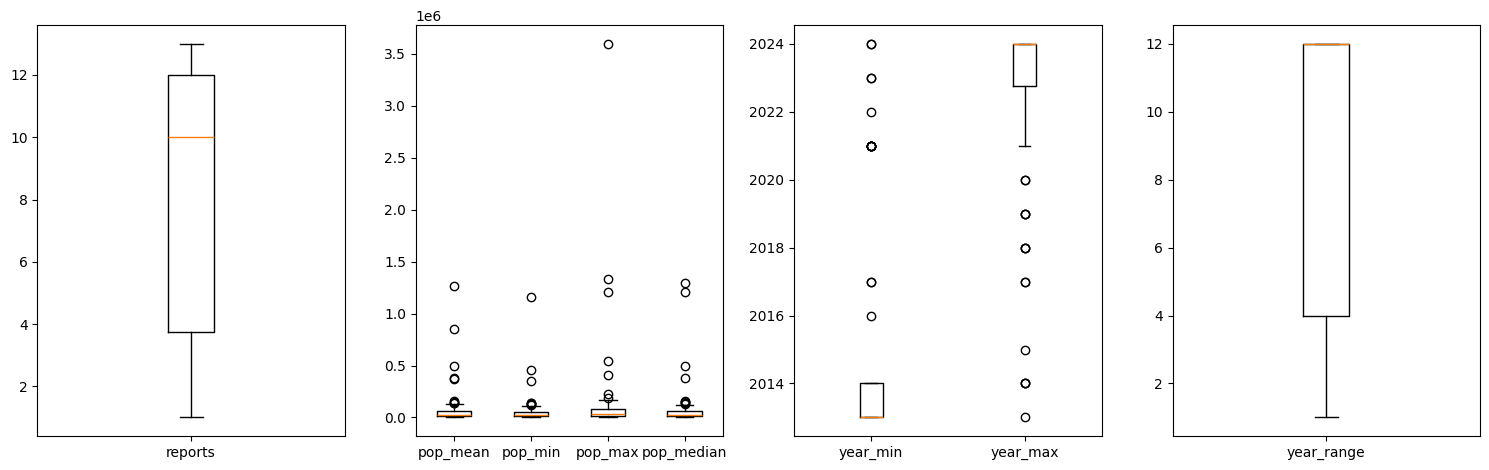

In [41]:
#___ examine stats (boxplots) of key columns across all ___#

fig_HB_reports_overview, ax_HB_reports_overview = plt.subplots(1,4)
fig_HB_reports_overview.set_figwidth(15)

ax_HB_reports_overview[0].boxplot(data_HB_providers['reports'],
                                  tick_labels=['reports'])
ax_HB_reports_overview[1].boxplot(data_HB_providers.loc[:,'pop_mean':'pop_median'],
                                  tick_labels=data_HB_providers
                                              .loc[:,'pop_mean':'pop_median']
                                              .columns)
ax_HB_reports_overview[2].boxplot(data_HB_providers.loc[:,'year_min':'year_max'],
                                  tick_labels=data_HB_providers
                                              .loc[:,'year_min':'year_max']
                                              .columns)
ax_HB_reports_overview[3].boxplot(data_HB_providers['year_range'],
                                  tick_labels=['year_range'])

fig_HB_reports_overview.tight_layout()

In [42]:
#___ sort all providers by # reports, year range, & avg population ___#

# XXX: already did this, without the avg population, defined above in 
# the info_HB_providers_top_reporting table
# keeping this for reference if needed, also for the use of head + shape 
# to get the full list of providers
# <2026-05-29>

# (data_HB_providers
#  .sort_values(['reports','year_range','pop_mean'],ascending=False)
#  .head(int(data_HB_providers.shape[0]/2)))

## Rate data

### CPI Adjustment

CPI typically considered as an annual metric, therefore will use annual CPI values rather than monthly or partial-year.

State of Colorado uses the **Denver-Aurora-Lakewood** CPI for budgeting ([link](https://dlg.colorado.gov/inflation-denver-aurora-lakewood-consumer-price-index)) so we will match that.

Using the imported CPIs, will convert all rates into their 2025-equivalent to normalize the cost for inflation using the following equation:

    Price_1 = Price_0 * (CPI_1 / CPI_0)

In [43]:
#__ import CPI data from BLS __#
ref_CPI = fxn_CPI_load(filename='CPI_Denver-Aurora-Lakewood_BLS_20260114.xlsx')
ref_CPI.head()

,CPI
Date,
1964-01-01,28.3
1965-01-01,28.8
1966-01-01,29.7
1967-01-01,30.0
1968-01-01,30.7


### Categories Tracking

In [44]:
# a reminder of the list of categories used in the 1051HB data
pd.DataFrame(info_HB_categories)

,Customer Category
1,Commercial / Industrial
2,Irrigation
5,"Residential, Multi Family"
6,"Residential, Single Family"
11,Utility/Municipal
14,Bulk/Wholesale
26,SF and MF Residential Combined
235,Other
1674,Mixed Use


In [45]:
#___ import new reference list of categories for use with household data ___#
ref_categories = fxn_excel_import(file_path='utility-data/_Rates/Rates Research.xlsx',
                                  inc_sheets='end',
                                  index_col=[0,1])
ref_categories

name  \
group                   code                                                    
Agriculture             irrigation                                 Irrigation   
All                     all                                     All Customers   
Commercial / Industrial commercial                                 Commercial   
                        commercial-industrial         Commercial / Industrial   
                        industrial                                 Industrial   
Other                   bulk                                   Bulk/Wholesale   
                        mixed                                       Mixed Use   
                        non-res                           All Non-Residential   
                        other                                           Other   
Residential             res-MF                      Residential, Multi Family   
                        res-MF-small                    Residential, Small MF   
                        res-SF                     Residential, Single Family   
                        res-combined           SF and MF Residential Combined   
                        res-duplex                        Residential, Duplex   
                        res-no-budget            Non-Water-Budget Residential   
Utility/Municipal       utility-municipal                   Utility/Municipal   

                                                                                           notes  
group                   code                                                                      
Agriculture             irrigation                                                           NaN  
All                     all                                                                  NaN  
Commercial / Industrial commercial                                                           NaN  
                        commercial-industrial                                                NaN  
                        industrial                                                           NaN  
Other                   bulk                                                                 NaN  
                        mixed                                                                NaN  
                        non-res                                                              NaN  
                        other                                                                NaN  
Residential             res-MF                                                      as in 1051HB  
                        res-MF-small                                                         NaN  
                        res-SF                 as in 1051HB, might include subcategories as a...  
                        res-combined                                                         NaN  
                        res-duplex                               grouped with res-SF (foco_city)  
                        res-no-budget                                                        NaN  
Utility/Municipal       utility-municipal                                                    NaN

### Utility Rates

In [46]:
print(f'2025 CPI: {ref_CPI.loc['01-01-2025'].values}')

2025 CPI: [335.07]


In [47]:
#___ importing the collected rates data for all providers ___#
data_rates = fxn_excel_import(file_path='utility-data/_Rates/Rates Research.xlsx',
                              inc_sheets=-3,
                              og_sheet_names=True, 
                              index_col=[0,1,2],
                              skiprows=1,
                              usecols='A:M',
                              names=['Category','Date','start'] + [i + j 
                                                                   for j in ['1','2','3','4','5'] 
                                                                   for i in ['cap_','rate_']])

for i in data_rates.keys():
    #___ calculate rates adjusted for inflation ___#
    data_rates[i] = data_rates[i].join(ref_CPI)
    data_rates[i]['CPI'] = data_rates[i]['CPI'].ffill()

    for col in [i + j for j in ['1','2','3','4','5'] for i in ['rate_']]:
        data_rates[i][f'adj_{col}'] = (data_rates[i]
                                       .apply(lambda x: fxn_inflation_adjuster(
                                                            x[col],
                                                            x['CPI'],
                                                            ref_CPI.loc['01-01-2025']
                                                        ),
                                              axis = 1))
    data_rates[i].drop(columns='CPI',inplace=True)
    data_rates[i].sort_index(axis=1,inplace=True)

    #___ create multiindex for columns, sort so rates & caps are split (prep for graphing) ___#
    data_rates[i].columns = pd.MultiIndex.from_product([['Rate per Unit (adjusted)',
                                                         'Tier Cap',
                                                         'Rate per Unit'],
                                                        [i + j 
                                                         for j in ['1','2','3','4','5'] 
                                                         for i in ['Tier ']]
                                                       ])
    # XXX: data_rates[i] = data_rates[i].reorder_levels([1,0],axis=1).sort_index(axis=1)
    data_rates[i] = data_rates[i].reset_index('start')
    data_rates[i][('Tier Cap','Tier 0')] = data_rates[i]['start']
    data_rates[i].drop(columns=[('start','')],inplace=True)
    data_rates[i].sort_index(axis=1,inplace=True)

    #___ calculate difference between tiers for graphing ___#
    if i not in ['denver_water']: 
    # TODO: denver have complex tier calculations that need to be processed -- str processing issue
    # (wait until get household use first)
        for n in list(range(data_rates[i]['Tier Cap'].columns.size-1,0,-1)):
            data_rates[i][('Tier Cap Diff',f'Tier {n}')] = (data_rates[i]['Tier Cap']
                                                            .apply(lambda x: np.nan 
                                                                            if isinstance(x.iloc[0],str) 
                                                                            else x.iloc[n]-x.iloc[n-1],
                                                                axis=1))
        # .iloc[:,n] - data_rates[i]['Tier Cap'].iloc[:,n-1]
    data_rates[i][('Tier Cap Diff','Tier 0')] = data_rates[i]['Tier Cap'].iloc[:,0]# - data_rates[i]['start']
    # data_rates[i][('Tier Cap Diff','Tier 0')] = data_rates[i]['start']
    data_rates[i].sort_index(axis=1,inplace=True)

# TODO : rates graph for Boulder: apply % formatting to tier rates

In [48]:
def plt_rates(provider,category,adjusted=False,ax=None,steps=False,**kwargs):
    '''
    for creating individual historical rate plots
    can be used by itself or as an axis in an existing figure

    Parameters
    ----------
    provider : str
        The provider id.
    category : str
        The category to plot rates for.
    adjusted : bool, default `False`
        If `True`, plot the nominal rates.
        If `False`, plot the inflation-adjusted rates.
    ax : plt.Axes, default `None`
        An existing axes to create the plot on.
        If `None`, will create a new axes.
    steps : bool, default `False`
        Whether to format the plot as a stepped-line and -area graph.
    **kwargs
        Optional kwargs to pass to ... # TODO
    
    Returns
    -------
    plt.Axes
    '''

    fig, ax = hlpr_check_for_plots(ax=ax)

    axTiers = ax

    if adjusted == True:
        rates_type = ' (adjusted)'
    else:
        rates_type = ''

    rates_units = info_utilities.loc[provider,'rates_units']

    # figRates, axTiers = plt.subplots(figsize=(9,5))

    the_colors = {'area':['grey','powderblue','xkcd:light grey green',
                          'navajowhite','lightpink','thistle'],
                 'lines':['steelblue','xkcd:army green','sienna',
                          'maroon','purple']} 
    # using CSS Colors list unless marked as xkcd
    # yellow: area-'lemonchiffon' & lines-'goldenrod'

    #___ create the area plot for the tier sizes ___#
    axTiers.stackplot(data_rates[provider].loc[category].index,
                      data_rates[provider].loc[category]['Tier Cap Diff'].T,
                      colors=the_colors['area'],
                      step='post' if steps else None,
                     )
    axTiers.set_ylim((0,None))
    axTiers.set_ylabel(f'Tier Size ({rates_units})')
    # axTiers.legend(labels=['Tier'])

    #___ create the rates lines plot on the same axes ___#
    axRates = axTiers.twinx()
    for i in list(range(5)):
        axRates.plot(data_rates[provider]
                     .loc[category][f'Rate per Unit{rates_type}']
                     .iloc[:,i], # ' (adjusted)'
                     drawstyle='steps-post' if steps else 'default',
                     color=the_colors['lines'][i])
    axRates.set_ylim((None,None))
    axRates.set_ylabel(f'Rate ($/{rates_units})')

    #___ set the color for the top tier by coloring the background ___#
    for i in list(range(5)):
        if data_rates[provider].loc[category]['Tier Cap Diff'][f'Tier {i+1}'].isna().all():
            top_area = i+1
            break
        else:
            continue
    else:
        top_area = np.nan
    axTiers.set_facecolor(the_colors['area'][top_area])

    # plt.autoscale(enable=True, axis='x', tight=True)
    axTiers.set_xlim(data_rates[provider].loc[category].index.min(),data_rates[provider].loc[category].index.max())
    # axTest2.legend()
    axTiers.set_title(f'{info_utilities.loc[provider,'name']} ({category})')
    hlpr_center_xtick_labels(ax=axTiers,rotation=30)

    axTiers.grid(True,axis='x')

In [49]:
def plt_rates_all_categories(provider, **kwargs):
    '''
    combines individual rate plots into 1 graph for all categories of a given provider
    ONLY for individual plot use (not for use in existing figures)

    Parameters
    ----------
    provider : str
        The account_id of the utility of interest
    **kwargs
        kwargs to pass into `plt_rates`
    
    Returns
    -------
    plt.Figure
    '''
    #___ get categories from kwargs or use all categories ___#
    try:
        categories = kwargs.pop('category')
    except:
        categories = data_rates[provider].index.get_level_values(0).unique().to_list()

    #___ create figure for rates with an axes for each category ___#
    fig_rates, ax_rates = plt.subplots(nrows=categories.__len__(), ncols=2)
    fig_rates.set_figwidth(15) # default: 6.4
    fig_rates.set_figheight(4.8 * fig_rates.get_axes().__len__()/2 * 0.75)    

    # if categories.__len__()>1 else ax_rates[0]

    #___ plot each rates category's rates in 1 figure ___#
    i = 0
    for category in categories:
        if categories.__len__()>1:
            ax_rates_row = ax_rates[i]
        else:
            ax_rates_row = ax_rates
        fig_rates.suptitle(f'{info_utilities['name'].drop_duplicates().loc[provider]} Rate Structures for {ref_categories.reset_index(level=0).loc[category]['name']} Accounts')
        plt_rates(provider,category,ax=ax_rates_row[0],**kwargs)
        plt_rates(provider,category,adjusted=True,ax=ax_rates_row[1],**kwargs)

        # ax_rates_row[1].set_title(f'{ax_rates_row[1].get_title()} -- adjusted to 2025 CPI')
        ax_rates_row[0].set_title('with rate prices as listed')
        ax_rates_row[1].set_title('with rate prices adjusted for inflation to 2025 equivalent')
        # for j in [0,1]:
        #     hlpr_center_xtick_labels(ax=ax_rates_row[j],rotation=30)
        i += 1
    fig_rates.tight_layout()

## 🐯 Household data

In [50]:
info_utilities.loc['boulder_city']

name               Boulder
rates_units           kgal
acct_data_units        gal
Name: boulder_city, dtype: object

In [51]:
error_log = False

#___ define data groups -- must match exactly in csv filenames ___#
data_household_groups = ['structures','accounts','account_units','usage','population']

#___ load in existing csv data files for each provider (using account_id) & each group ___#
data_household = dict.fromkeys(info_participants)
for provider in data_household: # set groups for each provider
    data_household[provider] = dict.fromkeys(data_household_groups)
for provider in data_household.keys(): # load data into each group for each provider
    try:
        for group in data_household_groups:
            # import csv for each group if exists
            try: 
                data_household[provider][group] = pd.read_csv(f'utility-data/z_household_imports/{provider}_{group}.csv')
                # set id as index when available
                if 'id' in data_household[provider][group].columns: 
                    data_household[provider][group] = data_household[provider][group].set_index('id').sort_index()
                # convert monthly data column headers to datetime datatype
                if group == 'usage': 
                    data_household[provider][group].columns = pd.to_datetime(data_household[provider][group].columns)
                else:
                    # if years are used for the column headers, convert column name datatype to int32
                    try: 
                        data_household[provider][group].columns = data_household[provider][group].columns.astype('int32')
                    except:
                        pass
            # if file not found for group, check for split files (e.g., by year) and make df from all found
            except: 
                continue                
    except:
        continue
    # check for yearly template files for the provider
    finally: 
        try:
            for n in ['usage','budget']:
                if error_log: print(f'starting loop for: {provider} -- {n}')
                files = []
                #___ get list of files that match search ___#
                src = '' if n=='usage' else f'_{n}'
                for file in glob.glob(f'utility-data/z_household_imports/{provider}_template{src}_[0-9]*.csv'):
                    files += [file]
                if error_log: print('files have been read')
                #___ read each file into a df & concat them all together (parsing date column at same time) ___#
                template_df = pd.concat((pd.read_csv(x,
                                                    dtype={'id':int,n:float,'category':str,'notes':str}|({'type':str} if n=='budget' else {}),
                                                    parse_dates=[1],
                                                    date_format={'date':'%Y-%m-%d'},
                                                    comment='#') for x in files),
                                        ignore_index=True)
                if error_log: print('concatenated df of files has been made')
                #___ drop duplicate id & date (& type) entries (keep largest 'usage'|'budget' value) | fxn also sets & sorts index ___#
                template_df = fxn_df_duplicates(template_df,
                                                columns=['id','date']+(['type'] if n=='budget' else []),
                                                type='drop',
                                                sort_col=[n])
                if error_log: print('duplicates dropped')
                #___ budget only: aggregate by id & date, combining across budget types ___#
                if n=='budget':
                    template_df = template_df.reset_index().groupby(by=['id','date','type'],as_index=False).agg({'budget':'sum','category':'first','notes':'first'}).drop(['type'],axis=1).set_index(['id','date'])
                if error_log: print('summed over budget types')
                #___ aggregate by month (sum only usage|budget), set to month start, to simplify data
                template_df = template_df.groupby([pd.Grouper(level='id'),
                                                   pd.Grouper(level='date',freq='MS')]
                                                 ).agg({n:'sum','category':'first','notes':'first'}) # ,'Residential Customer Category':'first'
                if error_log: print('dataframe created')
                data_household[provider][n] = template_df[n].unstack()
                if n=='usage':
                    data_household[provider]['accounts'] = template_df['category'].unstack()
                # NOTE not currently creating df for 'notes'
                if error_log: print(f'completed loop for: {provider} -- {n}')
                del src, files, template_df
        except Exception as error:
            if error_log: print(f'template error for {provider}:',type(error).__name__,'-',error)
            continue
        finally:
            cleaned_dict = {}
            for key, value in data_household[provider].items():
                if type(value) is pd.DataFrame:
                    if not value.empty:
                        cleaned_dict[key] = value
                elif value is not None:
                    cleaned_dict[key] = value
            data_household[provider] = cleaned_dict
            del cleaned_dict

del error_log
# TODO: consider implementing the convention of starting temp vars with "_" <2026-05-30>

In [52]:
def fxn_usage_filter(provider,group=[],category=[],
                     time_endcaps_only=False,dropna='all',
                     match_units_to_rates=True,error_log=False,
                     **time_kwargs):
    '''
    Filters household usage data by provider, timeframe, and other.

    Parameters
    ----------
    provider : str
        The account_id of the utility of interest.
    group : list, default `[]`
        The category group(s), connects to ref_categories['group']. 
    category : list, default `[]`
        The category(ies), connects to ref_categories['code'].
    time_endcaps_only : bool, default `False`
        Whether to return only the data at the chosen start & end values (`True`)
        or to return all data within the range (`False`).
    dropna : {'all','any',`False`}, default 'all'
        Designiates how to handle `NaN` values in the filtered dataset:
        - 'all': drops rows that have all `NaN` values 
                 (particularly useful for time filters, but 
                 should match shape of "False" when no time filters used)
        - 'any': drops rows that have at least 1 `NaN` value
                 (can be useful if finding issues with calculating differences)
        - `False`: does not drop any rows with `NaN`s
    match_units_to_rates : bool, default `True`
        If `True`, converts data to use the same units as the rates are in
        as defined in the table `info_utilities`
    error_log : bool, default `False`
        Whether to print error logging information.
    **time_kwargs
        Keyword arguments for what time filter to apply.
        All values in the dict must be `int`.
        Can be in any 1 of the following combinations
        (if none are specified, will return all columns):
        - 'year_start','year_end','month': 1 entry for each selected year for chosen month
        - 'month_start','month_end','year': 1 entry for each selected month for chosen year
        - 'year_start','year_end': monthly data for duration
        
    Returns
    -------
    dict of pd.DataFrame
        A dictionary of dataframes containing processed data.
        - 'usage_df': The filtered usage
        - 'budget_df': Only if the provider has an allocation budget
        - 'acct_units_df': Only if provider has # of units per account

    Notes
    -----
    was thinking about adding this, don't think I need it anymore
    - dataset : {'usage','budget'}
    '''
    categories_df = ref_categories.reset_index()
    categories_df = categories_df.loc[(categories_df['group'].isin(group))
                                      + (categories_df['code'].isin(category)),
                                      :]
    
    usage_df = data_household[provider]['usage']
    accounts_df = data_household[provider]['accounts']
    structures_df = data_household[provider]['structures'] if 'structures' in data_household[provider].keys() else None
    acct_units_df = data_household[provider]['account_units'] if 'account_units' in data_household[provider].keys() else None
    if 'budget' in data_household[provider].keys():
        budget_df = data_household[provider]['budget']
        # df_list = [usage_df,budget_df]
        df_dict = {'usage_df':usage_df,'budget_df':budget_df}
    else:
        # df_list = [usage_df]
        df_dict = {'usage_df':usage_df}
    
    #___ get codes as used by the provider as defined by the filter ___#
    try:
        code_filter = structures_df[structures_df['group_code'].isin(categories_df['code'])]['structure_code'].to_list()
    except:
        code_filter = categories_df['code'].to_list()

    #___ filter account id's that have no match for any of the strucutre codes ___#
    accounts_df = accounts_df[accounts_df.isin(code_filter)].dropna(how='all').index
    for df in df_dict.values():
        accounts_df = accounts_df.intersection(df.index)

    #___ select only the usage & units data for account id's included in the above list ___#
    for df in df_dict.keys():
        df_dict[df] = df_dict[df].loc[accounts_df]
    if type(acct_units_df) is pd.DataFrame:
        acct_units_df = acct_units_df.loc[accounts_df]

    #___ filter columns based on chosen time parameters ___#
    def time_range(start,end):
        return [start,end] if time_endcaps_only else list(range(start,end+1))

    try:
        time_start,time_end = [time_kwargs[key] for key in ['year_start','year_end']]
        try:
            [time_select] = [time_kwargs[key] for key in ['month']]
            for df in df_dict.keys():
                df_dict[df] = df_dict[df].sort_index(axis=1,key=lambda col: col.month + (col.year * 0.0001))
        except:
            time_select = []
        finally:
            for df in df_dict.keys():
                df_i = df_dict[df]
                df_dict[df] = df_i.loc[:,df_i.columns.year.isin(time_range(time_start,time_end))]
                if time_select: df_dict[df] = df_dict[df].loc[:,df_dict[df].columns.month==time_select]
            if type(acct_units_df) is pd.DataFrame:
                acct_units_df = acct_units_df.loc[:,acct_units_df.columns.isin(time_range(time_start,time_end))]
    except:
        try:
            time_select,time_start,time_end = [time_kwargs[key] for key in ['year','month_start','month_end']]
            for df in df_dict.keys():
                df_i = df_dict[df]
                df_dict[df] = df_i.loc[:,(df_i.columns.month.isin(time_range(time_start,time_end))) & (df_i.columns.year==time_select)]
        except:
            pass

    if dropna in ['any','all']:
        for df in df_dict.keys():
            df_dict[df] = df_dict[df].dropna(how=dropna)
        if type(acct_units_df) is pd.DataFrame:
            acct_units_df = acct_units_df.dropna(how=dropna)

    units_check = info_utilities[['rates_units','acct_data_units']].loc[provider].to_list()
    if units_check[0] is not units_check[1] and match_units_to_rates:
        if error_log:
            print('converting to match rates units...')
            print(f'starting units: {units_check[1]}, target units: {units_check[0]}')
        for df in df_dict.keys():
            df_dict[df] = df_dict[df].pipe(fxn_convert_to_gallons,units=units_check[1],target_unit=units_check[0])
            if error_log: print('dataframe converted')

    return df_dict | ({'acct_units_df':acct_units_df} if type(acct_units_df) is pd.DataFrame else {})

In [53]:
fxn_usage_filter('boulder_city',category=['res-SF'],year_start=2016,year_end=2018,month=6)['usage_df'].head()

date,2016-06-01,2017-06-01,2018-06-01
id,,,
1,6.0,4.0,2.0
2,17.0,12.0,7.0
13,3.0,0.0,4.0
16,3.0,2.0,2.0
18,3.0,3.0,4.0


In [54]:
### NOTE: FORT COLLINS RECORDS PROCESSING ###

# (4639425, 3) -- all records
# (4636682, 1) -- after dropping duplicates (id's & dates) -- also set indices
# (4560840, 1) -- after aggregating (sum) over each month 
#                 => not sure if we *want* to do this though? 
#                    makes it easier for widening the table though...
# (92604, 143) -- after unstacking: household id's in rows, months in columns (1/2014 through 11/2025)

# TODO: add this sort of reporting as an `error_log` in the function <2026-05-30>

In [55]:
# TODO: add pre-calc descriptions & info (in markdown parts)

In [56]:
# XXX: some old code, not sure if needed but should verify first

# df['account_usage'] = {}
# for id in df['usage'].index:
#     df['account_usage'][id] = pd.DataFrame(df['usage'].loc[id].T).sort_index().rename(columns={id:'usage'})

# df['account_usage'][sel_id]['year'] = df['account_usage'][sel_id].index.year
# df['account_usage'][sel_id].join(df['accounts'].loc[sel_id].T,on=['year']).rename(columns={sel_id:'structure_code'})\
#     .join(df['account_units'].loc[sel_id].T,on=['year']).rename(columns={sel_id:'units'}).drop(columns='year').head()

# Analysis

## Define key variables

In [57]:
# sel_provider = 'westminster_city'
# sel_provider = 'foco_city'
sel_provider = 'boulder_city'

sel_category = 'res-SF'

data_rates[provider].head()

Rate per Unit                              \
                           Tier 1 Tier 2 Tier 3 Tier 4 Tier 5   
Category Date                                                   
all      2010-01-01          2.06   2.75   5.50   8.25  13.75   
         2011-01-01          2.18   2.90   5.80   8.70  14.50   
         2012-01-01          2.25   3.00   6.00   9.00  15.00   
         2013-01-01          2.32   3.09   6.18   9.27  15.45   
         2014-01-01          2.42   3.23   6.46   9.69  16.15   

                    Rate per Unit (adjusted)                                 \
                                      Tier 1    Tier 2    Tier 3     Tier 4   
Category Date                                                                 
all      2010-01-01                 3.249018  4.337282  8.674564  13.011845   
         2011-01-01                 3.315898  4.411057  8.822115  13.233172   
         2012-01-01                 3.357146  4.476194  8.952389  13.428583   
         2013-01-01                 3.368253  4.486164  8.972328  13.458492   
         2014-01-01                 3.418505  4.562715  9.125431  13.688146   

                               Tier Cap                                     \
                        Tier 5   Tier 0 Tier 1 Tier 2 Tier 3 Tier 4 Tier 5   
Category Date                                                                
all      2010-01-01  21.686409        0    0.6      1    1.5      2    NaN   
         2011-01-01  22.055287        0    0.6      1    1.5      2    NaN   
         2012-01-01  22.380971        0    0.6      1    1.5      2    NaN   
         2013-01-01  22.430821        0    0.6      1    1.5      2    NaN   
         2014-01-01  22.813577        0    0.6      1    1.5      2    NaN   

                    Tier Cap Diff                                     
                           Tier 0 Tier 1 Tier 2 Tier 3 Tier 4 Tier 5  
Category Date                                                         
all      2010-01-01             0    0.6    0.4    0.5    0.5    NaN  
         2011-01-01             0    0.6    0.4    0.5    0.5    NaN  
         2012-01-01             0    0.6    0.4    0.5    0.5    NaN  
         2013-01-01             0    0.6    0.4    0.5    0.5    NaN  
         2014-01-01             0    0.6    0.4    0.5    0.5    NaN

## GPCD

resample good for quick convserion from months to days
- creates intervening days if missing (i.e. Feb & Apr given, still fills through March)
  - but **ffill** fills through those added days, so would incorrectly add data for months that were not included originally
  - WORKAROUND: **resample('MS').asfreq()** to insert NaN where months are missing, then **resample('D').ffill()** to upsample to daily and fill values (excludes any pre-existing NaN values, which we inserted with the first resample)
- stops at the end, so need to add the following month to upsample the entire final month (i.e. add 01/01/2025 so that Dec 2024 expands to the month)

### 1051HB Data

> make gcpd function to handle not only the combined residential?

In [58]:
#___ calculate GCPD from the 1051HB data for the selected provider ___#
   # NOTE: currently uses only the combined residential category <2026-05-30>
data_HB_gpcd = (data_HB_metered['residential']['combined']
                .loc[(sel_provider,slice(None),'Potable Treated')]
                .join(data_HB_population['yearly'])
                .reset_index(['DNR 1051 Report Name','account_id','Report Year']
                             ,drop=True)
                .sort_index()
                [['Metered Use (gallons)',
                  'Permanent Residential Population',
                  'Transient Population',
                  'Total Population'
                ]])
data_HB_gpcd = fxn_gpcd(data_HB_gpcd)

data_HB_gpcd.head()

,GPCD,Total Population,Permanent Residential Population,Transient Population
date,,,,
2013-01-01,36.820892,143621,113621,30000
2013-02-01,42.802261,143621,113621,30000
2013-03-01,34.501564,143621,113621,30000
2013-04-01,38.023298,143621,113621,30000
2013-05-01,43.128236,143621,113621,30000


## GPCD Plot

includes:
  - rate trends
  - gpcd metered usage
  - population
    - if a given population = 0 for all reports, will only show the other
    - select "total" or "both":
      - calculate usage based on total population
      - show either both non-zero populations or just a total population graph
    - select "permanent" or "transient":
      - calculate usage based only on the selected type
        - *do we need this? or should it just always calculate based on total?*
      - show only the selected pop type

linked closely to **fxn_gpcd**

💭 making a loop through all (or a selection) of the cities & exporting/ saving each as an image to look at (rather than manually looking through multiple)

🧋 [ Sam Stein ] `We noticed that some accounts are reporting either very low or zero metered used for a given report. For Aurora's 2023 report, it looks like there is a discrepancy in the reported metered use and the reporting units (the volume matches closer to the 2022 report using Gallons Thousands, but it is labelled as being reported in Gallons). Boulder reported 0 acre-feet for its 2018-2020 residential usage -- and it looks like the 2018 report was entirely a zero-volume report for all categories. Similar data gaps exist with some population reports, such as with Parker Water and Sanitation District, which reported 0 population for 2017 and 2022. Do you have any advice on how to proceed with interpreting reporting oddities like these?`

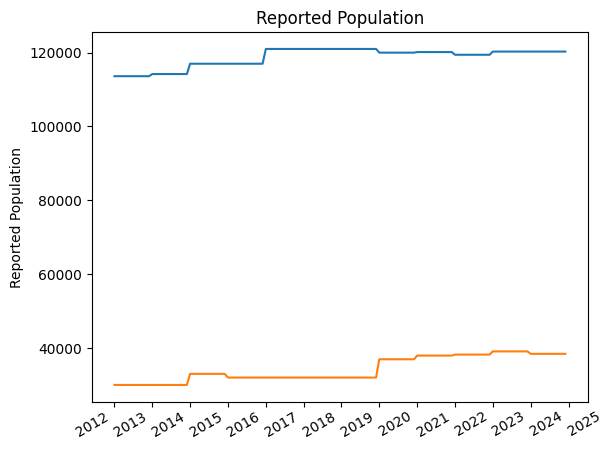

In [59]:
plt_GPCD_population(data_HB_gpcd)

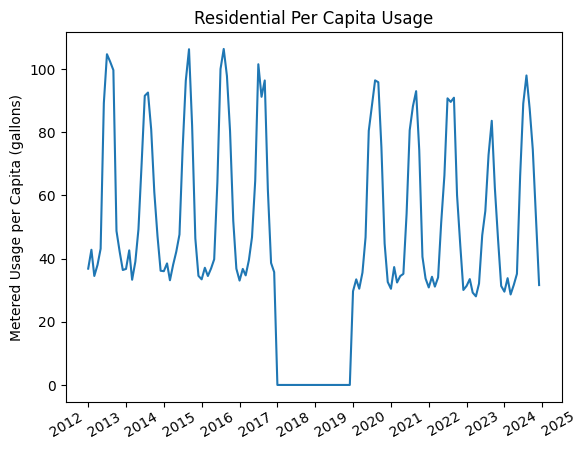

In [60]:
plt_GPCD(data_HB_gpcd)

In [67]:
def plt_GPCD_combined_fig(data_gpcd,data_rates,
                          account_id,pop_type='both',
                          show_both_pop=False, 
                          category='Residential, Single Family', 
                          df_return=all):
    '''
    df_return: 'all','head','none'
    '''
    
    xaxis = pd.DataFrame({'date':data_gpcd.index.to_series()})
    xlim = (xaxis.index.min(),xaxis.index.max())

    title = info_utilities['name'].loc[account_id]
    
    fig_GPCD = plt.figure(figsize=[14, 7])
    fig_GPCD.suptitle(title)

    if account_id in data_rates.keys() and category in data_rates[account_id].index:
        grid_shape = (5,2)
        i = 0

        ax_GPCD_rates = plt.subplot2grid(grid_shape,(0,0),rowspan=2)
        plt_rates(provider=account_id,category=category,ax=ax_GPCD_rates,steps=True)
        ax_GPCD_rates.set_title(f'Rates Implemented ({category})')

        # ax_GPCD_rates_adj = plt.subplot2grid(grid_shape,(0,1),rowspan=1)
        # plt_rates(provider=account_id,category=category,adjusted=True,ax=ax_GPCD_rates_adj)
    else:
        grid_shape = (1,2)
        i = 2
        fig_GPCD.set_figheight(4)
    
    ax_GPCD_usage = plt.subplot2grid(grid_shape,(2-i,0),rowspan=3-i)
    plt_GPCD(data_gpcd=data_gpcd,ax=ax_GPCD_usage)

    ax_GPCD_pop = plt.subplot2grid(grid_shape,(2-i,1),rowspan=3-i)
    plt_GPCD_population(data_gpcd=data_gpcd,pop_type=pop_type,show_both_pop=show_both_pop,ax=ax_GPCD_pop)

    for ax in fig_GPCD.get_axes():
        ax.set_xlim(xlim)
        hlpr_center_xtick_labels(ax=ax,rotation=30)

    fig_GPCD.tight_layout()

    plt.savefig(f'1051graphs/{account_id}_GPCD.png')
    plt.show()

    if df_return == 'all':
        return data_gpcd
    elif df_return == 'head':
        return data_gpcd.head()
    
    #-X old rates code, keeping for reference formatting if needed X-#
        # ax_GPCD_rates.set_title('Rates Implemented')
        # ax_GPCD_rates.stackplot(data_rates['Westminster, City of'].index,
        #                         data_rates['Westminster, City of']['Gal Cap']['Tier 1'],
        #                         data_rates['Westminster, City of']['Gal Cap']['Tier 2 ']-data_rates['Westminster, City of']['Gal Cap']['Tier 1'],
        #                         colors=['black','grey'])
        # ax_GPCD_rates.set_ylabel('Tier Size (gallons)')
        # ax_GPCD_rates.xaxis.set_major_locator(mdates.YearLocator())
        # ax_GPCD_rates.tick_params(axis='x', rotation=30)
        # ax_GPCD_rates2 = ax_GPCD_rates.twinx()
        # ax_GPCD_rates2.plot(data_rates['Westminster, City of']['Rate (USD $)'])
        # ax_GPCD_rates2.set_ylabel('Rate ($/gal)')

    # axTest2.legend()

> check population gaps (see Parker)

> also check gaps in usage (see Boulder)

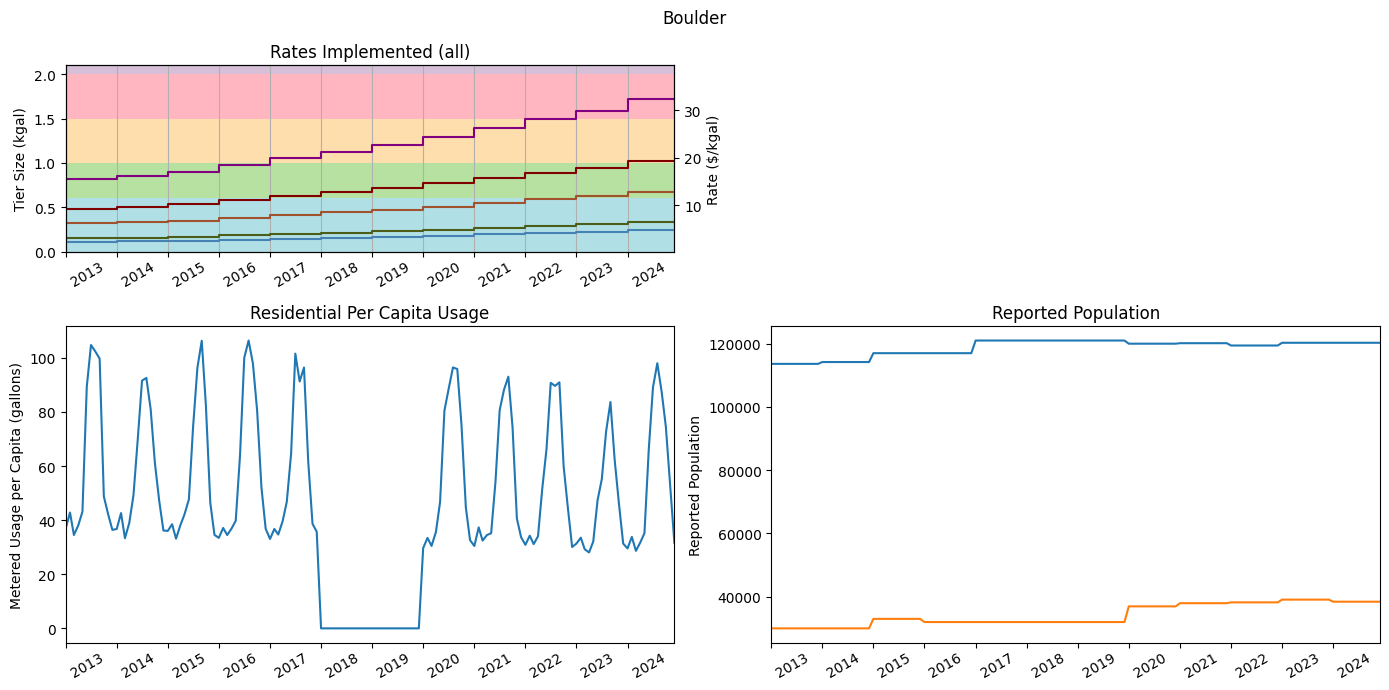

,GPCD,Total Population,Permanent Residential Population,Transient Population
date,,,,
2013-01-01,36.820892,143621,113621,30000
2013-02-01,42.802261,143621,113621,30000
2013-03-01,34.501564,143621,113621,30000
2013-04-01,38.023298,143621,113621,30000
2013-05-01,43.128236,143621,113621,30000


In [68]:
plt_GPCD_combined_fig(data_gpcd=data_HB_gpcd,
                      data_rates=data_rates,
                      account_id=sel_provider,
                      pop_type='both',df_return='head',
                      category='all')#,show_both_pop=True)
# longmont          ->  ,category='Residential'
# greeley, pueblo   ->  ,category='Single Family Residential'

## Rates Plot

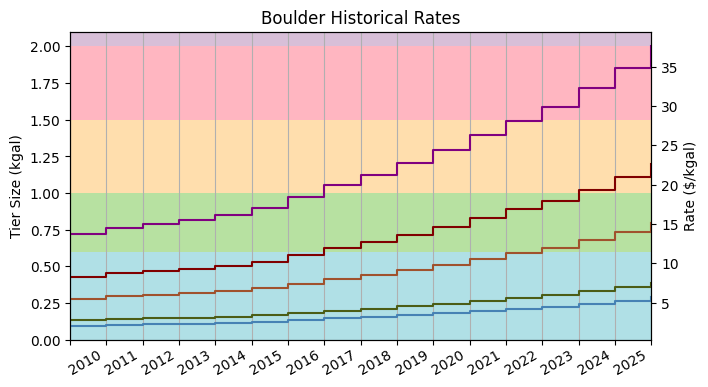

In [69]:
#___ create rates + tiers plot ___#
fig_rates, ax_rates = plt.subplots(figsize=(7.5,4))
try:
    # plot for selected category if it exists for the provider's rates
    plt_rates(provider=sel_provider,category=sel_category,steps=True,adjusted=False)
except:
    # plot for the general category "all" if selected category does not exist
    # NOTE: what if they don't have an 'all' category? <2026-05-30>
    plt_rates(provider=sel_provider,category='all',steps=True,adjusted=False)
ax_rates.set_title(f'{info_utilities.loc[sel_provider]['name']} Historical Rates')
plt.show()
# TODO: in plt_rates function, add caveat for if a greater group is used <2026-05-13>
    # TODO: consider moving that checker code into a function since it's used in a couple spots

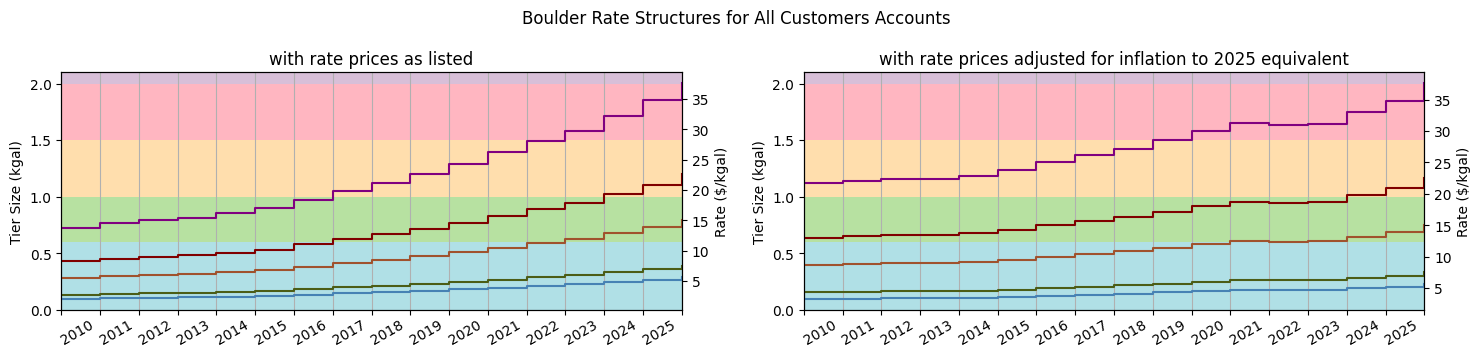

In [70]:
#___ plot all rate schedules, alongside CPI adjusted rates ___#

# TODO: need to account for if the rate category is not chosen/ avoid empty rate figs <2026-05-30>

# try:
#     plt_rates_all_categories(sel_provider,steps=True,category=[sel_category])
# except:
plt_rates_all_categories(sel_provider,steps=True,category=['all'])
# data_rates[sel_provider].head()



## Bill Costs

Block structure bill calculations:
$$
    [p_1 * (w_1 - w_0)] + [p_2 * (w_2 - w_1)] + ... + [p_n * (w - w_{n-1})]
$$
$$
    = \sum 
    \begin{cases}
        p_n * (w_n - w_{n-1}),& \text{if } w\geq w_n\\
        p_n * (w - w_{n-1}),&   \text{if } w\lt w_n
    \end{cases}
$$

In [170]:
# TODO: add citation for tiered bill calculation above <2026-05-30>

In [ ]:
def fxn_calc_bill(provider,category,head=False,adjusted=False,error_log=False,**kwargs):
    '''Calculate customer bills from historical rate and water use data

    Uses imported datasets to calculate the water bill for each customer account. Does not include fixed fees.

    Parameters
    ----------
    provider : str
        The `'account_id'` for the desired water utility.
    category : str
        The customer category to filter by. Connects to the `'accounts'` rate code (e.g., `'res-SF'`) in the household dataset
    head : bool or int, default `False`
        Whether to only return the top n rows of the dataframe, useful for testing. If `False`, will return the entire dataframe.
        If an integer is passed, will return that many rows from the top of the dataframe.
    adjusted : bool, default `False`
        Whether to use rates that have been adjusted for inflation.
    error_log : bool or int, default `False`
        Whether to print calculation progress as a means of error checking.
    **kwargs
        to pass into fxn_usage_filter
    
    Returns
    -------
    df_bills : pd.DataFrame
        The table of calculated account bills
    df_ref : dict of pd.DataFrame
        Returns a dictionary of the composite dataframes used in the calculations
    '''
    # NOTE account for # of units in a given account

    #___ get rates/tiers category based on provided customer category ___#
    category_rates = data_rates[provider].reset_index()['Category'].drop_duplicates().to_list()
    if category in category_rates:
        category_applied = category
    elif (ref_categories.reset_index('group').loc[category]['group']=='Residential' 
          and 'res-combined' in category_rates):
        category_applied = 'res-combined'
    elif 'all' in category_rates:
        category_applied = 'all'
    else:
        raise('category mismatch between rates and accounts')

    #___ create tiers & rates dataframes based on category ___#
    df_t = data_rates[provider].loc[category_applied,'Tier Cap']
    if adjusted == True:
        rates_type = ' (adjusted)'
    else:
        rates_type = ''
    df_r = data_rates[provider].loc[category_applied,f'Rate per Unit{rates_type}']
    
    #___ get usage & budget & account units based on category ___#
    filter = fxn_usage_filter(provider,category=[category],**kwargs)
    df_u = filter['usage_df'] if 'usage_df' in filter.keys() else None
    df_b = filter['budget_df'] if 'budget_df' in filter.keys() else None
    df_n = filter['acct_units_df'] if 'acct_units_df' in filter.keys() else None
        
    if head and not error_log:
        df_u = df_u.head(head)

    if error_log:
        # filter usage for chosen or random account
        if error_log in df_u.index:
            df_u = df_u.loc[error_log]
        else:
            df_u = df_u.sample(n=1)
        # filter budget & account units df's if they exist to match new usage
        try:
            df_b = df_b.loc[df_u.index]
        except:
            pass
        try:
            df_n = df_n.loc[df_u.index]
        except:
            pass

    #___ put dataframes together in a reference dictionary ___#
    df_ref = {'u':df_u,'n':df_n,'t':df_t,'r':df_r}

    #___ build bills df from usage index & columns ___#
    df_bills = pd.DataFrame(index=df_u.index,columns=df_u.columns)
    
    #___ calculate bills ___#
    for row in df_u.index:
        test_col = 0
        if error_log: print(f'Account ID: {row}')
        for col in df_u.columns:
            u = df_u.loc[row,col]
            b = df_b.loc[row,col] if type(df_b) is pd.DataFrame else None
            try:
                get_acct_units = df_n.loc[row,col.year]
            except:
                get_acct_units = 1
            get_rates = df_r.iloc[df_r.index.get_indexer([col],method='pad')]
            get_tiers = df_t.iloc[df_t.index.get_indexer([col],method='pad')]
            if b:
                get_tiers_adj = get_tiers * b
            else:
                get_tiers_adj = get_tiers * get_acct_units
            get_tier_sizes = get_tiers_adj.where(get_tiers_adj<=u).fillna(value=u,axis=1,limit=1).diff(axis=1) 
            get_tier_costs = get_rates * get_tier_sizes
            get_bill = get_tier_costs.agg('sum',axis=1)
            df_bills.loc[row,col] = get_bill.iloc[0]
            if error_log and test_col==0:
                print(f'Date: {col:%Y-%m-%d}\n')
                print(f'Metered Use: {u} {info_utilities.loc[provider,'rates_units']}\n')
                if b: print(f'Budget: {b} {info_utilities.loc[provider,'rates_units']}')
                print(f'# Units in Account: {get_acct_units}\n')
                print(f'Rates for {col:%Y-%m-%d}:')
                display(get_rates)
                print(f'\nRate Schedule Tier Caps for {col:%Y-%m-%d}:')
                display(get_tiers)
                print(f'\nEffective Tier Caps for Acct {row} at {col:%Y-%m-%d}')
                display(get_tiers_adj)
                print(f'\nAmount used across tiers:')
                display(get_tier_sizes.head())
                print(f'Cost per Tier:')
                display(get_tier_costs.head())
                print(f'Total Bill: ${get_bill.iloc[0]}')
            test_col += 1

    #___ correct for data weirdness by converting numbers to floats ___#
    df_bills = df_bills.astype(np.float64)

    # df_check = {'get_rates':get_rates,'get_tiers':get_tiers,'get_tier_sizes':get_tier_sizes,'get_tier_costs':get_tier_costs}
    if not error_log:
        return df_bills, df_ref#, df_check

    ########################################################################################

    #___ trying to speed up the code... but I broke it lol so leaving it here for later ___#

    # '''
    # **kwargs to pass into fxn_usage_filter
    # '''
    # # account for # of units in a given account
    # df_u, df_n = fxn_usage_filter(provider,category=[category],**kwargs)
    # df_t = data_rates[provider].loc[category,'Tier Cap']
    # df_r = data_rates[provider].loc[category,'Rate per Unit']

    # # print(df_u.shape)

    # # df_u, df_n = df_u.head(1000), df_n.head(1000)

    # df_bills = pd.DataFrame(index=df_u.index,columns=df_u.columns)
    # for col in df_u.columns:
    #     get_rates = df_r.iloc[df_r.index.get_indexer([col],method='pad')]
    #     get_tiers = df_t.iloc[df_t.index.get_indexer([col],method='pad')]
    #     get_acct_units = df_n.loc[:,col.year]
    #     # get_tiers = get_tiers.merge(get_acct_units.reset_index()['id'],how='cross').set_index('id').mul(get_acct_units,axis=0)
    #     for row in df_u.index:
    #         x = df_u.at[row,col]
    #         # get_acct_units = df_n.loc[row,col.year]
    #         get_tiers = get_tiers * get_acct_units.at[row]
    #         get_tier_sizes = get_tiers.where(get_tiers<=x).fillna(value=x,axis=1,limit=1).diff(axis=1) 
    #         get_tier_costs = get_rates * get_tier_sizes
    #         get_bill = get_tier_costs.sum(axis=1)
    #         df_bills.at[row,col] = get_bill.iat[0]
    
    # df_bills = df_bills.astype(np.float64)

    # df_ref = {'u':df_u,'n':df_n,'t':df_t,'r':df_r}

    # df_check = {'get_rates':get_rates,
    #             'get_tiers':get_tiers,
    #             'get_tier_sizes':get_tier_sizes,
    #             'get_tier_costs':get_tier_costs
    #             }

    # return df_bills, df_ref, df_check

In [ ]:
#___ LONG-RUNNING CODE, RUN ONLY ONCE FOR A GIVEN SUBSET, SAVES TO CSV TO LOAD IN ___#

# data_bills, data_ref = fxn_calc_bill(provider=sel_provider,category=sel_category,adjusted=False)
# data_bills.to_csv(f'utility-data/z_bills/{sel_provider}_{sel_category}_bills.csv',chunksize=1000)
# with open(f'utility-data/z_bills/{sel_provider}_{sel_category}_ref.pickle','wb') as pickle_file:
#     pickle.dump(data_ref, pickle_file)

# del data_bills, data_ref
    
###   T I M I N G   N O T E S   ###

# "at" replaced `loc` with `at` within the inner loop

# westminster, res-SF
    # loc, full timespan, to_csv() == 148 minutes to calculate bills
    # loc, 2018, June, head() == 1m 11.4s ... 13.9s
    #  at, 2018, June, head() == 1m 10.8s ... 13.4s
    #  ^^^^, removed astype() == 1m  5.9s --> except that "at" still results in dtype object, so still need to set the type...

# TODO: this could probably be cleaned up... <2026-05-30>

### Load Files

In [190]:
#___ read external, pre-calculated bills df back into notebook ___#
data_bills = pd.read_csv(f'utility-data/z_bills/{sel_provider}_{sel_category}_bills.csv',index_col=0)
data_bills.columns = pd.to_datetime(data_bills.columns)
with open(f'utility-data/z_bills/{sel_provider}_{sel_category}_ref.pickle','rb') as pickle_file:
    data_bills_ref = pickle.load(pickle_file)

In [191]:
data_bills.describe()

,2014-01-01,2014-02-01,2014-03-01,2014-04-01,2014-05-01,2014-06-01,2014-07-01,2014-08-01,2014-09-01,2014-10-01,2014-11-01,2014-12-01,2015-01-01,2015-02-01,2015-03-01,2015-04-01,2015-05-01,2015-06-01,2015-07-01,2015-08-01,2015-09-01,2015-10-01,2015-11-01,2015-12-01,2016-01-01,2016-02-01,2016-03-01,2016-04-01,2016-05-01,2016-06-01,2016-07-01,2016-08-01,2016-09-01,2016-10-01,2016-11-01,2016-12-01,2017-01-01,2017-02-01,2017-03-01,2017-04-01,2017-05-01,2017-06-01,2017-07-01,2017-08-01,2017-09-01,2017-10-01,2017-11-01,2017-12-01,2018-01-01,2018-02-01,2018-03-01,2018-04-01,2018-05-01,2018-06-01,2018-07-01,2018-08-01,2018-09-01,2018-10-01,2018-11-01,2018-12-01,2019-01-01,2019-02-01,2019-03-01,2019-04-01,2019-05-01,2019-06-01,2019-07-01,2019-08-01,2019-09-01,2019-10-01,2019-11-01,2019-12-01,2020-01-01,2020-02-01,2020-03-01,2020-04-01,2020-05-01,2020-06-01,2020-07-01,2020-08-01,2020-09-01,2020-10-01,2020-11-01,2020-12-01,2021-01-01,2021-02-01,2021-03-01,2021-04-01,2021-05-01,2021-06-01,2021-07-01,2021-08-01,2021-09-01,2021-10-01,2021-11-01,2021-12-01,2022-01-01,2022-02-01,2022-03-01,2022-04-01,2022-05-01,2022-06-01,2022-07-01,2022-08-01,2022-09-01,2022-10-01,2022-11-01,2022-12-01,2023-01-01,2023-02-01,2023-03-01,2023-04-01,2023-05-01,2023-06-01,2023-07-01,2023-08-01,2023-09-01,2023-10-01,2023-11-01,2023-12-01,2024-01-01,2024-02-01,2024-03-01,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01,2025-04-01,2025-05-01,2025-06-01,2025-07-01,2025-08-01,2025-09-01,2025-10-01,2025-11-01,2025-12-01
count,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000,23173.000000
mean,10.463661,10.462823,8.429199,9.491298,14.659525,23.022091,35.309914,35.237091,28.661054,21.982599,13.731565,10.079915,11.474288,9.651328,9.032448,10.444014,12.249399,14.022550,28.360743,43.286356,50.518262,40.327110,15.262833,9.824718,10.985229,10.645612,10.418296,10.408987,12.063322,24.443539,47.721996,54.828357,47.864912,40.896766,22.972101,12.678926,9.309880,7.911381,8.811869,10.224286,0.107001,20.360744,43.062695,43.500656,36.916964,19.858809,9.270952,15.118594,15.055145,13.915078,13.145893,12.594012,18.701937,37.766627,56

## Elasticity

- usage difference
- bill difference
- comparison

**Price Elasticity:** percentage change in water demand in response to a 1% change in price

Elasticity equation:

$$
    \varepsilon = \frac{\frac{\Delta w}{w}}{\frac{\Delta p}{p}} = \frac{\Delta w}{\Delta p} * \frac{p}{w}
$$

***$w$ demanded falls as $p$ rises, $\therefore$ $\varepsilon <0$ (demand slope, water (x) vs price (y) is negative)***

when demand is price **inelastic:** $-1<\varepsilon <0$
- 1% change in price induces a < %1 change in water use

when demand is price **elastic:** $\varepsilon <-1$

> source: Griffin 2006 p.31-32 (Chapter 2)

Dalhuisen study (referenced by Griffin 2006)
- annual, long-term elasticities
- 314 residential elasticities -- range from **-7.47 to +7.90**
- culling outliers from highest & lowest 5% -- new range **-1.233 to +0.1** for now 282 observations

**"Modern price elasticities for annual water use are likely to lie in the *-0.35 to -0.45* range"**



Typical water demand calculation based on price elasticity:

$$
Q=cP^\varepsilon
$$

### Plots

In [192]:
def fxn_df_diff(data: pd.DataFrame,ax=None,lim=None,percent_diff=False):
    '''
    Calculates the difference in values across columns in a DataFrame.
    Displays date range as new column headers.

    Parameters
    ----------
    data : pd.DataFrame
        The data to calculate the difference for.
        Must have DateTimeIndex as column headers
    percent_diff : bool, default `False`
        Whether to calculate the percent change across columns.
    
    Returns
    -------
    pd.DataFrame
        The data with the column-wise differences calulated.
        Excludes the placeholder "empty" column that the `diff()` and `pct_change()`
        functions include by default.
        Column headers are automatically formatted to show the date range across
        which the difference was calculated.
    
    Example
    -------
    ```
    use.pipe(fxn_df_diff,percent_diff=True)
    ```
    '''
    # df = data_household[provider]['usage']

    # if time_diff == 'year':
    #     df = df.sort_index(axis=1,key=lambda col: col.month + (col.year * 0.0001))
    #     try:
    #         df = df.loc[:,(df.columns.year.isin([kwargs['year_start'],kwargs['year_end']])) & (df.columns.month==kwargs['month'])]
    #         df = df.diff(axis=1).iloc[:,[1]]
    #         df.columns = [f'{df.columns.month_name()[0]}: {kwargs['year_start']} vs {kwargs['year_end']}']
    #     except:
    #         df = df.diff(axis=1)
    # else:
    #     try:
    #         df = df.loc[:,(df.columns.month.isin([kwargs['month_start'],kwargs['month_end']])) & (df.columns.month==kwargs['year'])]
    #         df = df.diff(axis=1).iloc[:,[1]]
    #         df.columns = [f'{kwargs['year']}: {cal.month_name[kwargs['month_start']]} vs {cal.month_name[kwargs['month_end']]}-{kwargs['year']}']
    #     except:
    #         df = df.diff(axis=1)
    
    if percent_diff:
        df = data.pct_change(axis=1,fill_method=None).iloc[:,1:]
    else:
        df = data.diff(axis=1).iloc[:,1:]
    
    new_columns = []
    for i in range(1,data.shape[1]):
        if data.columns[i].year == data.columns[i-1].year:
            new_columns += [f'{cal.month_name[data.columns[i].month]}-{cal.month_name[data.columns[i-1].month]}, {data.columns[i].year}']
        elif data.columns[i].month == data.columns[i-1].month:
            new_columns += [f'{cal.month_name[data.columns[i].month]}, {data.columns[i].year}-{data.columns[i-1].year}']

    df.columns = new_columns

    # fig, ax = hlpr_check_for_plots(ax)

    # fig = plt.figure()
    # fig.set_layout_engine('constrained')
    # subfigs = fig.subfigures(1,2)
    
    # axsL = subfigs[0].subplots()
    # df.boxplot(ax=axsL)
    # if lim:
    #     axsL.set_ylim(-lim,lim)

    # axsR = subfigs[1].subplots()
    # # plt.figure(fig.subfigs[1])
    # df.hist(ax=axsR,grid=False)
    # axsR = plt.gca()
    # axsR.set_xlim(-25,25)    
    
    # # fig, ax = plt.subplots(1,2)

    # # plt.tight_layout()
    

    #     # df_plot = fxn_usage_filter('westminster_city',category=['res-SF'],time_endcaps_only=True,year_start=2018,year_end=2020,month=6).diff(axis=1).iloc[:,[1]]

    #     # fig, ax = plt.subplots(1,2)

    #     # df_plot.boxplot(ax=ax[0])
    #     # ax[0].set_ylim(-25,25)

    #     # df_plot.hist(ax=ax[1], grid=False)
    #     # # ax[1].set_xlim(-25,25)

    #     # plt.tight_layout()
    #     # plt.show()

    return df

In [193]:
def fxn_elasticity(data_use:pd.DataFrame,data_bills:pd.DataFrame,
                   filter_out_change_in_units=False,remove_use_diff_outliers=False,
                   price_diff_bound=False,use_dropna=True,
                   y_data='price',compare=None,
                   show_plots=True,hist_range='all',scatter_alpha=0.1,
                   ret_elas_df=False,export_to_png=False,investigate=False,elas_IQR=False,describe=True,
                   error_checking_return_local_vars=False):
    '''
    Calculates elasticity from water usage and total bills.
    
    TODO: add references & specifics for how this is being calulated <2026-06-01>

    Parameters
    ----------
    data_use : pd.DataFrame or tuple
        The source of water usage data in a DataFrame, 
        or a tuple of DataFrames where the first element holds the water usage
        and the second element holds data of number of units in each account 
        (matching the shape and indices of the first element).
        Must have a DateTimeIndex for the column names.
    data_bills : pd.DataFrame
        The source of total bills data with the same shape and indices as the usage.
        Must have a DateTimeIndex for the column names.
    filter_out_change_in_units : bool, default `False`
        If `True`, filters out data whose number of units changed across the dataset.
        Requires `data_use` to be a tuple with the second element containing 
        the number of units in each account.
    remove_use_diff_outliers : bool, default `False`
        If `True`, removes outliers from the `data_use` water usage data before
        doing any calculations. Filters the same accounts with that outlier data from
        the `data_bills` dataset as well.
    price_diff_bound : `False` or float, default `False`
        If a value between 0 and 1 is passed, will only include accounts whose calculated
        percent difference of the average price is less than the value passed.
    use_dropna : bool, default `True`
       If `True`, filters the usage data to exclude any rows with a `NaN` value
       (uses the default `how=any` parameter in the `pd.DataFrame.dropna()` function).
    y_data : {'price','bills'}, default 'price'
        Which data to use on the y-axis of the resulting plots.
        Has no effect if `show_plots` is `False`.
    compare : dict, default `None`
        A dict of y-axis values and dates to plot side-by-side for ease of comparison.
        For example:
        ```
        compare = {
            'y_data': ['price','bills']
            ,
            'dates': [{'start':'2018-01-01',
                       'end':'2020-01-01'},
                      {'start':'2021-01-01',
                       'end':'2023-01-01'}]
        }
        ```
    show_plots : bool, default `True`
        If `True`, displays plots of elasticity.
    hist_range : 'all' or float, default 'all'
        The range of the histogram to plot.
        Has no effect if `show_plots` is `False`.
    scatter_alpha : float, default 0.1
        The opacity of the points of the scatter plot.
    ret_elas_df : bool, default `False`
        If `True`, returns a DataFrame with the elasticity values.
    export_to_png : bool, default `False`
        If `True`, saves the scatter plot and histogram as separate `.png` files
        to the folder `utility-data/z_graph_exports/elasticity`.
    investigate : {`False`,int,'min','max'}, default `False`
        If an integer (of an account), 'min', or 'max' is passed, will return key
        values for the selected account for further investigation.
        Note: minimum and maximum values are based on the calculated elasticity.
    elas_IQR : bool, default `False`
        Removes outliers of the elasticity before plotting.
        Incompatible with `price_diff_bound`.
        Has no effect if `show_plots` is `False`.
    describe : bool, default `True`
        If `True`, displays a table with descriptive statistics for elasticity.
    error_checking_return_local_vars : bool, default `False`
        If `True`, prints local variables for error checking.
    '''

    df_elas_dict = {}
    df_described = {}
    compare = {} if compare is None or compare.__class__ is not dict else compare

    if data_use.__class__ is tuple:
        data_units = data_use[1]
        data_use = data_use[0]
    else:
        filter_out_change_in_units=False
        data_units = None

    if 'dates' not in compare.keys() and data_use.shape[1] > 2:
        compare['dates'] = []
        for i in range(data_use.shape[1]-1):
            compare['dates'] += [{'start':data_use.columns[i].strftime('%Y-%m-%d'),
                                  'end':data_use.columns[i+1].strftime('%Y-%m-%d')}]

    if show_plots:
        fig_rows = compare['dates'].__len__() if 'dates' in compare.keys() else 1
        fig_cols = compare['y_data'].__len__() if 'y_data' in compare.keys() else 1
        fig_xy, ax_xy = plt.subplots(nrows=fig_rows,ncols=fig_cols,
                                    figsize=(6*fig_cols,4*fig_rows))
        # TODO: should fix so not using global vars
        # fig_xy.suptitle(f'{sel_provider} ({sel_category}), 
        # for {'unchanged' if filter_out_change_in_units else 'all'} 
        # units{', use_diff IQR only' if remove_use_diff_outliers else ''}')
        fig_xy.suptitle(f'Changes of {info_utilities['name'].drop_duplicates().loc[sel_provider]}:\
                         {ref_categories.reset_index(level=0).loc[sel_category]['name']} Accounts')

        range_tuple = (-hist_range,hist_range) if hist_range != 'all' else None # for elas hist plot

        fig_hist, ax_hist = plt.subplots(nrows=fig_rows,ncols=fig_cols,
                                         figsize=(6*fig_cols,4*fig_rows))
        # TODO: fix so not using global vars
        fig_hist.suptitle(f'Elasticities of {info_utilities['name'].drop_duplicates().loc[sel_provider]}:\
                           {ref_categories.reset_index(level=0).loc[sel_category]['name']} Accounts')
        # f'{'elasticities' if not price_diff_bound else 'change in water use'}: {sel_provider} ({sel_category})\nfor {'unchanged' if filter_out_change_in_units else 'all'} units{', use_diff IQR only' if remove_use_diff_outliers else ''}')


    for i in range(compare['dates'].__len__()) if 'dates' in compare.keys() else [0]:

        use = data_use
        units = data_units
        
        if 'dates' in compare.keys():
            start = compare['dates'][i]['start']
            end = compare['dates'][i]['end']
            try:
                use = use.loc[:,[start,end]]
                if filter_out_change_in_units:
                    units = units.loc[:,[int(start[:4]),int(end[:4])]]
            except:
                print('At least one of the chosen dates for comparison was not found in the provided \
                      data_use table. Select a different date or expand the range of columns in data_use.')
        else:
            start = use.columns[0].strftime('%Y-%m-%d')
            end = use.columns[1].strftime('%Y-%m-%d')

        if filter_out_change_in_units:
            units_check = units[units.iloc[:,0]==units.iloc[:,1]]
            use = use.loc[units_check.index]
        
        if use_dropna:
            use = use.dropna(how='any')

        use_diff = use.pipe(fxn_df_diff,percent_diff=True)

        if remove_use_diff_outliers:
            use_diff = use_diff.pipe(fxn_remove_outliers)
            use = use.loc[use_diff.index]

        bills = data_bills
        bills.columns = pd.to_datetime(bills.columns)

        # to account for weirdness with data export where too many lines were dropped in the overall table, 
        # shouldn't need to use this down the line
        try:
            bills = bills.loc[use.index,use.columns]
        except:
            shared_index = use.index.join(bills.index,how='inner')
            use = use.loc[shared_index]
            use_diff = use_diff.loc[shared_index]
            bills = bills.loc[shared_index,use.columns]

        bills_diff = bills.pipe(fxn_df_diff,percent_diff=True)
        
        price = bills / use

        price_diff = price.pipe(fxn_df_diff,percent_diff=True)

        if price_diff_bound:
            price_diff = price_diff[abs(price_diff)<price_diff_bound].dropna()
            use_diff = use_diff.loc[price_diff.index]
            bills_diff = bills_diff.loc[price_diff.index]

        [water_x, price_y, bills_y, Delta] = [use_diff, price_diff, bills_diff, '$\\%\\Delta$ ']

        nice_ax_title = f'{water_x.columns[0][:4]}, {water_x.columns[0][-4:]} to {water_x.columns[0][-9:-5]}'

        for j in range(compare['y_data'].__len__()) if 'y_data' in compare.keys() else [0]:
            if 'y_data' in compare.keys():
                y_data = compare['y_data'][j]

            elas_col_title = f'{water_x.columns[0]} -- from {y_data}'
            
            money_y = price_y if y_data=='price' else bills_y

            df_elas = water_x / money_y # get elasticity
            if elas_IQR and not price_diff_bound:
                df_elas = df_elas.pipe(fxn_remove_outliers)

            if show_plots:
                if fig_rows > 1 and fig_cols > 1:
                    ax_xy_plot = ax_xy[i,j]
                    ax_hist_plot = ax_hist[i,j]
                elif fig_rows > 1:
                    ax_xy_plot = ax_xy[i]
                    ax_hist_plot = ax_hist[i]
                elif fig_cols > 1:
                    ax_xy_plot = ax_xy[j]
                    ax_hist_plot = ax_hist[j]
                else:
                    ax_xy_plot = ax_xy
                    ax_hist_plot = ax_hist

                ax_xy_plot.scatter(water_x,money_y,s=1,alpha=scatter_alpha)
                # ax_xy.set_aspect(1.)
                ax_xy_plot.set_ylabel(f'{Delta} {y_data}')
                ax_xy_plot.set_xlabel(f'{Delta}water')
                ax_xy_plot.axhline(c='k',lw=0.5)
                ax_xy_plot.axvline(c='k',lw=0.5)
                # ax_xy.set_xlim((-lim,lim))
                # ax_xy.set_ylim((-lim/10,lim/10))
                ax_xy_plot.set_title(nice_ax_title)

                if price_diff_bound:
                    # make histogram of change in water use instead of elasticities when looking at very small prices
                    water_x.hist(ax=ax_hist_plot)
                    ax_hist_plot.set_xlabel(f'{Delta} water use')
                else:
                    df_elas.replace([np.inf, -np.inf], np.nan).hist(bins=100,range=range_tuple,ax=ax_hist_plot)#.plot(kind='scatter')
                    ax_hist_plot.set_xlabel('elasticity')        
                # ax_hist_plot.set_title(elas_col_title)
                ax_hist_plot.set_title(nice_ax_title)

            if price_diff_bound:
                df_to_describe = water_x
                describe_col_title = water_x.columns[0]
            else:
                df_to_describe = df_elas
                describe_col_title = elas_col_title
            df_described[describe_col_title] = df_to_describe.replace([np.inf, -np.inf], np.nan).describe()
            
            df_elas_dict[elas_col_title] = df_elas

            if investigate:
                if investigate=='max':
                    inv_id = df_elas.idxmax()
                elif investigate=='min':
                    inv_id = df_elas.idxmin()
                else:
                    inv_id = [investigate]

                investigate_df_ij = pd.concat([df_elas.loc[inv_id],
                                               bills_y.loc[inv_id],
                                               price_y.loc[inv_id],
                                               water_x.loc[inv_id]],
                                               keys=['elasticity','bill change','price change','use change']
                                              ).reset_index('id')

                try:
                    investigate_df = investigate_df.join(investigate_df_ij,rsuffix=f'[{i},{j}]')
                except:
                    investigate_df = investigate_df_ij

    if show_plots:
        fig_xy.tight_layout()
        fig_hist.tight_layout()

        if compare:
            if 'y_data' in compare.keys():
                y_data_title = f'({')('.join(compare['y_data'])})'
            else:
                y_data_title = y_data
            
            if 'dates' in compare.keys():
                dates_title = f'({')('.join(['--'.join(compare['dates'][i][when][:-3] for when in ['start','end']) for i in range(compare['dates'].__len__())])})'
            else:
                dates_title = f'{start[:-3]}--{end[:-3]}'
        else:
            y_data_title = y_data
            dates_title = f'{start[:-3]}--{end[:-3]}'

        # NOTE should update the below code to not use global vars

        fig_title = f'{sel_category}_{dates_title}_{y_data_title}{'_IQR' if remove_use_diff_outliers else ''}\
            {'_units-no-chg' if filter_out_change_in_units else ''}{'_narrow' if price_diff_bound else ''}'

        if export_to_png:
            fig_xy.savefig(f'utility-data/z_graph_exports/elasticity/{sel_provider}/scatter_{fig_title}.png')
            fig_hist.savefig(f'utility-data/z_graph_exports/elasticity/{sel_provider}/hist_{fig_title}_rng-{hist_range}.png')

        plt.show()

    df_described = pd.concat(df_described, axis=1).droplevel(1,axis=1)
    df_described.columns = df_described.columns.str.split(' -- ',expand=True)
    if describe:
        display(df_described)
        print('\n%Δ bills')
        display(bills_diff.describe())
        print('\n%Δ water use')
        display(use_diff.describe())
        print('\n%Δ price')
        display(price_diff.describe())

    if investigate:
        print(f'investigating {investigate}')
        display(investigate_df)

    if error_checking_return_local_vars:
        local_vars = {}
        for var in locals():
            if type(locals()[var]) == pd.DataFrame or type(locals()[var]) == pd.Series:
                local_vars[var] = locals()[var].head()
                print(f'\n{var}:')
                display(local_vars[var])
            elif var=='df_elas_dict':# type(locals()[var]) == dict:
                local_vars[var] = locals()[var].keys()
                print(f'\n{var}: {local_vars[var]}')
            elif var=='local_vars':
                pass
            else:
                local_vars[var] = locals()[var]
                print(f'\n{var}: {local_vars[var]}')
        
    # print(local_vars)
    # print(locals()['data_use'].__class__ == pd.DataFrame)

    if ret_elas_df:
        return df_elas_dict

# display(price_diff.head())
# display(use_diff.head())
# display(use.shape)
# price.shape

For analysis:
- **filtering out outliers in the % change in water use**
    - users that had massive swings between the two time periods had other, non-price related factors that led to that change
    - therefore these are not applicable to this analysis and would erroneously impact the analysis
- **filtering out accounts whose qty of units changed between the time periods**
    - `westminster_city` has a strange qty change in 2020 where some accounts had their listed qty of units go way up
        - because their tier caps adjust based on the qty of units, this resulted in many accounts' bill and equivalent price descreasing drastically compared to the other accounts
    - for ease, filtering out all accounts that change qty of units
        - *need confirmation of the westminster 2020 unit qty's*

Selection of year ranges:
- *focus generally on years on either side of a significant change i.e. if price increase in 2019, choose 2018 and 2020*
- `westminster`
    - **2016-2018:** *baseline for comparison*
    - **2018-2020:** huge increase in prices for 2019
    - **2021-2023:** dramatic decrease in price in 2022 plus adjustments to tier sizes -- 3 changes over the course of that year
- `fort collins`
    - overall steady increases, no crazy jumps like westminster
    - largest price increases in 2014 and 2025, *but no household data in 2013 or 2026, so these aren't available for analysis*
    - **2022-2024:** somewhat notable price increase in 2023
    - ~~**2014-2016:** 2015 had an unchanged (or lowered for Tier 1) price~~ *no data for 2014*
    - **2021-2023:** 2022 had unchanged prices but crazy inflation which led to a dramatic adjusted decrease 

Things of note:
- `foco` reports usage in **gal** whereas `westminster` reports in **kgal**
    - will see much more fluctuations in water use for foco than westminster in this case
    - this is why for westminster we have a lot of "true zero" median elasticities and very few for foco
- negligible change in price => very small denominator in elasticity calculation => dominated by any change in water in numerator
- range of pct diff calculations will always be [-1,inf) --> $\%\Delta = (start - end) / start$
    - -1 --> has starting value, but no end
    - inf --> has ending value,l but no start
    > *how do/ should we account for these?* -- exclude accounts with `nan` for either entry, would maintain those with 0's

In [194]:
df_elas_kwargs = {
    'remove_use_diff_outliers':True,
    'filter_out_change_in_units':True,
    # 'price_diff_bound':0.01,
    'show_plots':False,
    'investigate':None,
    'elas_IQR':True,
    'ret_elas_df':True,
    'describe':False
}

In [195]:
# sel_month = '07'
sel_year_start = 2023
sel_year_end = 2025

In [199]:
for month_i in range(1,13):
      filtered_data = fxn_usage_filter(sel_provider,category=[sel_category],
                                       time_endcaps_only=True,
                                       year_start=sel_year_start,
                                       year_end=sel_year_end,
                                       month=month_i
                                       )
      df_elas_r = fxn_elasticity(data_use=tuple([filtered_data[k] for k in filtered_data.keys()]),
                                    data_bills=data_bills,
                                    remove_use_diff_outliers=True,
                                    # filter_out_change_in_units=True, # for westminster
                                    show_plots=False,
                                    investigate=None,
                                    ret_elas_df=True,
                                    describe=False,
                                )
      df_elas_r = list(df_elas_r.values())[0].replace([np.inf, -np.inf], np.nan)
      if month_i==1:
            data_elasticity = df_elas_r
      else:
            data_elasticity = data_elasticity.join(df_elas_r,how='outer')
del df_elas_r,filtered_data

data_elasticity.sort_index().head()

,"January, 2025-2023","February, 2025-2023","March, 2025-2023","April, 2025-2023","May, 2025-2023","June, 2025-2023","July, 2025-2023","August, 2025-2023","September, 2025-2023","October, 2025-2023","November, 2025-2023","December, 2025-2023"
id,,,,,,,,,,,,
1,-2.940789,NaN,0.000000,0.000000,3.594210,NaN,NaN,NaN,4.926282,NaN,6.450564,4.706948
2,0.000000,0.000000,-1.960526,2.940789,2.940789,2.940789,6.535088,0.950700,-1.512372,-1.095145,-2.614035,-1.960526
13,0.000000,0.000000,0.000000,-1.960526,0.000000,-2.352632,2.941386,0.627737,3.853099,2.093038,2.940789,NaN
16,0.000000,5.881579,0.000000,-2.940789,0.000000,0.000000,0.000000,0.000000,5.881579,5.881579,5.881579,-2.940789
18,NaN,0.000000,2.940789,0.000000,-1.817194,-1.960526,2.559473,0.827040,-1.255731,NaN,-4.830254,2.311941


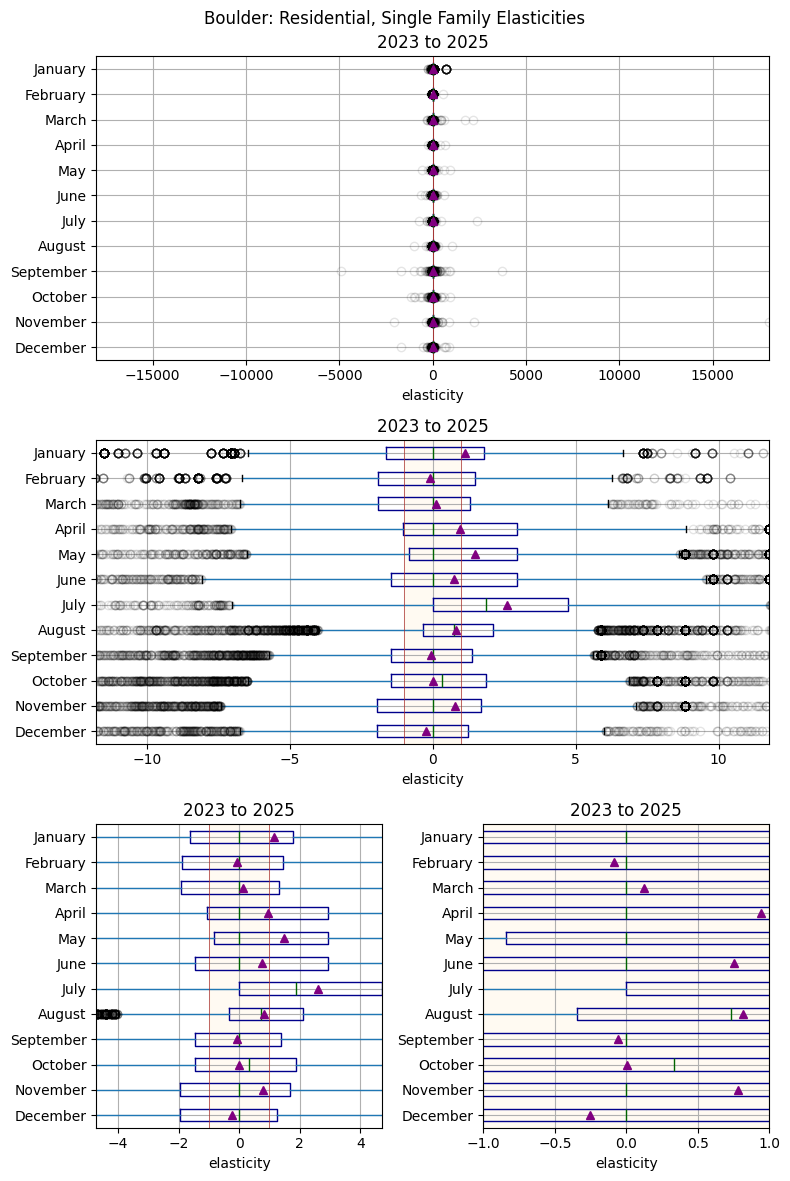

In [200]:
sel_i = None
gs_elas_box = (3,2) if sel_i is None else None
fig_elas_box = plt.figure()
if gs_elas_box:
    fig_elas_box.set_size_inches(8,12)

for i in range(4) if gs_elas_box else [sel_i]:
    if i == 0:
        ax_gs_pos = (0,0)
        ax_gs_cspan = 2
        ax_x_lim = abs(data_elasticity).max().max()
        ax_title = 'all values'
    elif i == 1:
        ax_gs_pos = (1,0)
        ax_gs_cspan = 2
        ax_x_lim = max(abs(data_elasticity.pipe(fxn_remove_outliers).min().min()),
                       abs(data_elasticity.pipe(fxn_remove_outliers).max().max()))
        ax_title = 'zoomed in past outliers (to whiskers range)'
    elif i == 2:
        ax_gs_pos = (2,0)
        ax_gs_cspan = 1
        ax_x_lim = max(abs(data_elasticity.describe().loc['25%'].min()),
                       abs(data_elasticity.describe().loc['75%'].max()))
        ax_title = 'focus on IQR'
    elif i == 3:
        ax_gs_pos = (2,1)
        ax_gs_cspan = 1
        ax_x_lim = 1
        ax_title = 'expected elasticity range (-1,1)'
    
    if gs_elas_box:
        ax_elas_box = plt.subplot2grid(gs_elas_box,ax_gs_pos,colspan=ax_gs_cspan)
    else:
        ax_elas_box = fig_elas_box.subplots()
    
    if ax_x_lim:
        ax_elas_box.set_xlim((-ax_x_lim,ax_x_lim))
    ax_elas_box.set_title(f'{sel_year_start} to {sel_year_end}')#ax_title,color='grey',fontsize=10)

    data_elasticity.boxplot(ax=ax_elas_box,showmeans=True,vert=False,
                            meanprops={'markerfacecolor':'purple',
                                       'markeredgecolor':'purple'},
                            flierprops={'alpha':0.1},
                            # whiskerprops={'color':'darkblue'},
                            boxprops={'color':'darkblue'},
                            medianprops={'color':'darkgreen'})
    ax_elas_box.invert_yaxis()

    inelastic_rng_line_color = 'brown'
    inelastic_rng_area_color = 'orange'
    inelastic_rng_area_alpha = 0.05

    ax_elas_box.set_yticklabels(ref_month_list)
    for vert_line in [-1,1]:
        ax_elas_box.axvline(vert_line,color=inelastic_rng_line_color,
                            linewidth=0.5)
    ax_elas_box.axvspan(-1,1,
                        color=inelastic_rng_area_color,
                        alpha=inelastic_rng_area_alpha)
    ax_elas_box.set_xlabel('elasticity')

fig_elas_box.suptitle(f'{info_utilities['name'].drop_duplicates().loc[sel_provider]}: {ref_categories.reset_index(level=0).loc[sel_category]['name']} Elasticities')# {sel_year_start} to {sel_year_end}')

# hlpr_center_xtick_labels(ax=ax_elas_box,rotation=30)

plt.tight_layout()
plt.savefig(f'utility-data/z_graph_exports/elasticity/boxplots/{sel_provider}_{sel_category}_{sel_year_end}-{sel_year_start}_monthly_elas_{'all_graphs' if gs_elas_box else sel_i}_{inelastic_rng_line_color}-{inelastic_rng_area_color}-{int(inelastic_rng_area_alpha*100)}({int((inelastic_rng_area_alpha*1000) % 10)}).png',
            dpi=200)
plt.show()

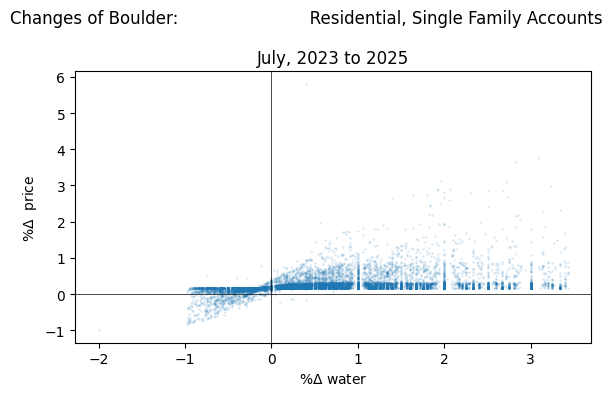

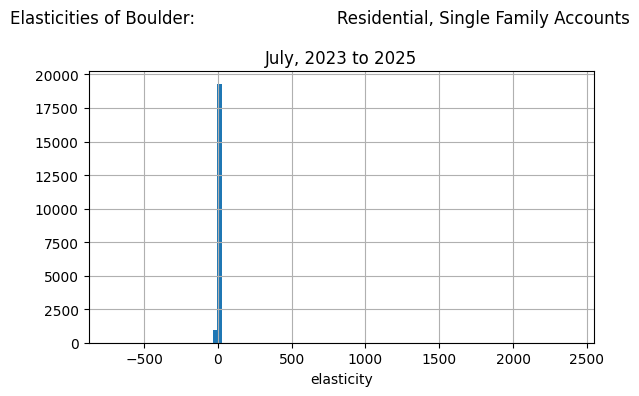

,"July, 2025-2023"
,from price
count,20224.000000
mean,2.610594
std,19.021566
min,-720.276969
25%,0.000000
50%,1.880183
75%,4.717415
max,2394.342677



%Δ bills


,"July, 2025-2023"
count,2.288300e+04
mean,inf
std,NaN
min,-1.000000e+00
25%,1.700224e-01
50%,7.940343e-01
75%,2.027567e+00
max,inf



%Δ water use


,"July, 2025-2023"
count,20724.000000
mean,0.542001
std,0.909488
min,-2.000000
25%,-0.057975
50%,0.384615
75%,1.000000
max,3.428571



%Δ price


,"July, 2025-2023"
count,2.180200e+04
mean,-inf
std,NaN
min,-inf
25%,1.700224e-01
50%,1.700224e-01
75%,2.307749e-01
max,5.810143e+00


In [ ]:
filtered_data = fxn_usage_filter(sel_provider,category=[sel_category],dropna='any'
                            ,time_endcaps_only=True,year_start=2023,year_end=2025,month=7
                            )
fxn_elasticity(data_use=tuple([filtered_data[k] for k in filtered_data.keys()]),
                        data_bills=data_bills,
                        #compare={
                        # 'y_data': ['price','bills']
                        # ,
                        # 'dates': [{'start':f'2018-{sel_month}-01','end':f'2020-{sel_month}-01'},{'start':f'2018-07-01','end':f'2020-07-01'}] # westminster
                        # 'dates': [{'start':f'2014-{sel_month}-01','end':f'2016-{sel_month}-01'},{'start':f'2023-{sel_month}-01','end':f'2025-{sel_month}-01'}] # foco
                        #},
                        remove_use_diff_outliers=True,
                        # filter_out_change_in_units=True,
                        # price_diff_bound=0.01,
                        # investigate='min',
                        # elas_IQR=True,
                        # hist_range=50
                        # scatter_alpha=0.01
                        )

> _something something_ calculating the line of 1:1 price per kgal increase to see who may have still used less water, just not enough less so they still show in the top right quadrant??

## 🐯 Statistic Models

- fixed effects regression model
    - look at Nick's paper ($\alpha$ term)

## Are all residential water types potable?

In [71]:
anls_water_type = (data_HB_metered['residential']['all']
                   .reset_index()[['DNR 1051 Report Name',
                                   'Water Type',
                                   'Customer Category']]
                   .drop_duplicates()
                   .groupby(['Customer Category','Water Type'])
                   .count())
# anls_water_type = anls_water_type.rename(columns={'DNR 1051 Report Name':'Qty Reports'})
# anls_water_type['Ratio of Total'] = anls_water_type['Qty Reports'] / anls_water_type['Qty Reports'].sum()

anls_water_type

DNR 1051 Report Name
Customer Category              Water Type                             
Residential, Multi Family                                            4
                               Non-Potable Raw                       2
                               Non-Potable Reuse                     1
                               Potable Treated                     359
Residential, Single Family                                           4
                               Non-Potable Reuse                     1
                               Potable Treated                     371
SF and MF Residential Combined Non-Potable Raw                      21
                               Non-Potable Reuse                     1
                               Potable Treated                     229

No, not all residential water types are potable -- though the vast majority are.

In [ ]:
#___ use this to pull up the list of metered use entries for a given water use type ___#

# metered['residential']['all'].loc[(slice(None),slice(None),slice(None),'Non-Potable Reuse')]

# Meta

In [81]:
# %who_ls function
%whos

Variable                          Type                          Data/Info
-------------------------------------------------------------------------
ax_HB_reports_overview            ndarray                       4: 4 elems, type `object`, 32 bytes
ax_rates                          Axes                          Axes(0.125,0.11;0.775x0.77)
cleaned_dict                      dict                          n=4
col                               str                           rate_5
data_HB_accounts                  DataFrame                     Shape: (76, 3)
data_HB_all_dict                  dict                          n=7
data_HB_counties                  DataFrame                     Shape: (725, 3)
data_HB_gpcd                      DataFrame                     Shape: (144, 4)
data_HB_metered                   dict                          n=8
data_HB_population                dict                          n=2
data_HB_programs                  DataFrame                     Shape: (8573, 